# PerformanceAnalysis: Break-it CPU Profiling and Optimization

This notebook is designed to:

1. profile where runtime is spent,
2. copy baseline hotspot logic into notebook-local implementations,
3. implement optimized notebook-local variants,
4. compare runtime and result parity (baseline vs optimized).

## Scope and measurement policy

- We profile simulation code only.
- We do **not** include plotting or figure display in timed/profiler sections.
- We isolate three layers:
  - micro hotspots (`encode`, nearest-cosine, DAM retrieval),
  - experiment-level loops,
  - break-it wrapper (`run_breakit_sweep`).

## Hotspot hypotheses to validate

- `DAM.update_neuron_differential`: repeated full `patterns @ state` inside each async step.
- `DAM.retrieve_differential`: periodic trace work (`energy` + similarity) inside retrieval loop.
- `utils.find_nearest_encoded`: Python loop over stored patterns with repeated norm/dot calls.
- `GridEncoder.encode`: nested Python loops + repeated small array allocations.

The goal is to determine what should be vectorized, where algorithmic updates are needed, and where optional JIT gives additional gains on CPU.

In [ ]:
import cProfile
import pstats
import time
from io import StringIO

import numpy as np

from experiments import run_breakit_sweep
from utils import cosine

np.set_printoptions(precision=5, suppress=True)

SEED = 20260409
np.random.seed(SEED)
print(f"Global NumPy seed set to {SEED}")

Global NumPy seed set to 20260409


In [ ]:
# Quick profile config: fast enough for iterative profiling.
QUICK_CFG = {
    "scale_factors": [1.4, 1.7, 2.0],
    "n_values": [3, 4],
    "K_values": [8, 16],
    "n_modules": 4,
    "n_orientations": 3,
    "n_cells_per_orientation": 4,
    "base_freq": 0.5,
    "noise_level": 0.1,
    "num_trials": 1,
    "num_test_points": 12,
    "steps_multiplier": 5,
}

# Medium profile config: closer to real behavior but still bounded.
MEDIUM_CFG = {
    "scale_factors": list(np.linspace(1.2, 2.6, 6)),
    "n_values": [3, 4],
    "K_values": [8, 16, 24],
    "n_modules": 4,
    "n_orientations": 3,
    "n_cells_per_orientation": 4,
    "base_freq": 0.5,
    "noise_level": 0.1,
    "num_trials": 2,
    "num_test_points": 24,
    "steps_multiplier": 8,
}


## Baseline copies (notebook-local)

The following code mirrors current hotspot implementations from `Encoder.py`, `utils.py`, and `DAM.py` so we can compare baseline vs optimized behavior in one place.

The reason I'm copying the baseline here is that in case we switch the implementation in DAM with the optimized approach, we can still check out the differences in performance between the original approach and the new one. Localizing performance comparisons here in this notebook.

In [ ]:
# Baseline constants and helpers
BASELINE_N_MODULES = 4
BASELINE_BASE_FREQ = 0.5
BASELINE_N_ORIENTATIONS = 3
BASELINE_N_CELLS_PER_ORI = 4


def baseline_cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)


def baseline_find_nearest_encoded(query_encoded, stored_encoded):
    query = query_encoded.flatten()
    similarities = np.array([baseline_cosine(query, p) for p in stored_encoded])
    return int(np.argmax(similarities))


class BaselineGridEncoder:
    """Near-verbatim baseline copy of GridEncoder.encode path."""

    def __init__(self, n_modules=3, n_orientations=3, n_cells_per_orientation=5, scales=None):
        self.n_modules = n_modules
        self.n_orientations = n_orientations
        self.n_cells_per_orientation = n_cells_per_orientation
        angles = np.linspace(0, np.pi, n_orientations, endpoint=False)
        self.orientations = np.stack([np.cos(angles), np.sin(angles)], axis=1)
        if scales is None:
            self.scales = np.sqrt(np.e) ** np.arange(n_modules)
        else:
            self.scales = np.asarray(scales)
        self.phases = 2 * np.pi * np.random.rand(
            n_modules, n_orientations, n_cells_per_orientation
        )

    def encode(self, x):
        x = np.atleast_2d(x)
        outputs = []
        for m, f in enumerate(self.scales):
            for o, k in enumerate(self.orientations):
                proj = 2 * np.pi * f * (x @ k)
                for p in range(self.n_cells_per_orientation):
                    phi = self.phases[m, o, p]
                    outputs.append(np.cos(proj + phi).reshape(-1, 1))
                    outputs.append(np.sin(proj + phi).reshape(-1, 1))
        result = np.concatenate(outputs, axis=1)
        return result.squeeze() if result.shape[0] == 1 else result


def baseline_create_multiscale_encoder(
    scale_factor,
    n_modules=BASELINE_N_MODULES,
    base_freq=BASELINE_BASE_FREQ,
    n_orientations=BASELINE_N_ORIENTATIONS,
    n_cells_per_orientation=BASELINE_N_CELLS_PER_ORI,
):
    scales = base_freq * (scale_factor ** np.arange(n_modules))
    return BaselineGridEncoder(
        n_modules=n_modules,
        n_orientations=n_orientations,
        n_cells_per_orientation=n_cells_per_orientation,
        scales=scales,
    )


def baseline_encode_points(encoder, points_2d):
    return np.asarray(encoder.encode(np.asarray(points_2d)))


def baseline_encode_single_point(encoder, point_2d):
    return np.asarray(encoder.encode(np.asarray(point_2d).reshape(2,)))


def baseline_find_nearest_neighbor_2d(query_2d, stored_2d_points):
    query = query_2d.flatten()
    distances = np.linalg.norm(stored_2d_points - query, axis=1)
    return int(np.argmin(distances))


class BaselineDAM:
    """Near-verbatim baseline copy of differential DAM retrieval path."""

    def __init__(self, patterns, n=4, beta=5.0, alpha=0.1, lmbda=0.0, verbose=False):
        self.patterns = np.array(patterns)
        self.K, self.N = self.patterns.shape
        self.n = n
        self.beta = beta
        self.alpha = alpha
        self.lmbda = lmbda
        self.verbose = verbose

    def F(self, x):
        return np.where(x > 0, x ** self.n, 0.0)

    def F_prime(self, x):
        return np.where(x > 0, self.n * (x ** (self.n - 1)), 0.0)

    def energy(self, state):
        projs = self.patterns @ state
        mem_term = -np.sum(self.F(projs))
        reg_term = (self.lmbda / 2.0) * np.sum(state ** 2)
        return mem_term + reg_term

    def update_neuron_differential(self, state, i):
        s_i = state[i]
        projections = self.patterns @ state
        F_primes = self.F_prime(projections)
        xi_column = self.patterns[:, i]
        mem_field = np.dot(xi_column, F_primes)
        reg_field = self.lmbda * s_i
        local_field = mem_field - reg_field
        new_val = np.tanh(self.beta * local_field)
        state[i] = (1.0 - self.alpha) * s_i + self.alpha * new_val
        return state

    def retrieve_differential(self, noisy_state, steps=500, update_indices=None, trace_every=10):
        state = noisy_state.copy()
        energy_trace = []
        similarity_trace = []

        if update_indices is None:
            update_indices = np.random.randint(0, self.N, size=steps)
        else:
            update_indices = np.asarray(update_indices, dtype=int)

        for t in range(steps):
            i = int(update_indices[t])
            state = self.update_neuron_differential(state, i)
            if trace_every > 0 and t % trace_every == 0:
                curr_sim = [
                    np.dot(state, p) / (np.linalg.norm(state) * np.linalg.norm(p) + 1e-12)
                    for p in self.patterns
                ]
                similarity_trace.append(curr_sim)
                energy_trace.append(self.energy(state))

        sims = [
            np.dot(state, p) / (np.linalg.norm(state) * np.linalg.norm(p) + 1e-12)
            for p in self.patterns
        ]
        best_idx = int(np.argmax(sims))
        best = self.patterns[best_idx]
        return state, best, energy_trace, similarity_trace, best_idx

In [ ]:
def baseline_multiscale_encoding_dim(n_modules, n_orientations, n_cells_per_orientation):
    return 2 * n_modules * n_orientations * n_cells_per_orientation


def baseline_identification_experiment_multiscale(
    scale_factors,
    n_values,
    K_values,
    noise_level=0.1,
    num_trials=5,
    steps_multiplier=20,
    n_modules=4,
    n_orientations=3,
    n_cells_per_orientation=4,
    base_freq=0.5,
    beta=0.01,
    alpha=0.5,
    lmbda=0.0,
):
    results = {}
    enc_dim = baseline_multiscale_encoding_dim(
        n_modules, n_orientations, n_cells_per_orientation
    )
    for c in scale_factors:
        results[c] = {}
        encoder = baseline_create_multiscale_encoder(
            c,
            n_modules=n_modules,
            base_freq=base_freq,
            n_orientations=n_orientations,
            n_cells_per_orientation=n_cells_per_orientation,
        )
        for n in n_values:
            results[c][n] = {}
            for K in K_values:
                successes = []
                similarities = []
                for _ in range(num_trials):
                    points_2d = np.random.uniform(-1, 1, (K, 2))
                    patterns_encoded = baseline_encode_points(encoder, points_2d)
                    dam = BaselineDAM(
                        patterns_encoded,
                        n=n,
                        beta=beta,
                        alpha=alpha,
                        lmbda=lmbda,
                        verbose=False,
                    )
                    steps = steps_multiplier * enc_dim
                    update_indices = np.random.randint(0, dam.N, size=steps)
                    for target_idx in range(K):
                        target_encoded = patterns_encoded[target_idx]
                        noisy_query = target_encoded + np.random.normal(0, noise_level, enc_dim)
                        retrieved, _, _, _, retrieved_idx = dam.retrieve_differential(
                            noisy_query,
                            steps=steps,
                            update_indices=update_indices,
                            trace_every=10,
                        )
                        successes.append(retrieved_idx == target_idx)
                        similarities.append(baseline_cosine(retrieved, target_encoded))
                results[c][n][K] = {
                    "accuracy": float(np.mean(successes) * 100),
                    "avg_sim": float(np.mean(similarities)),
                    "std_sim": float(np.std(similarities)),
                }
    return results


def baseline_generalization_experiment_multiscale(
    scale_factors,
    n_values,
    K_values,
    num_test_points=50,
    num_trials=5,
    steps_multiplier=20,
    n_modules=4,
    n_orientations=3,
    n_cells_per_orientation=4,
    base_freq=0.5,
    beta=0.01,
    alpha=0.5,
    lmbda=0.0,
    sample_2d_fn=None,
):
    def sample_points(shape):
        if sample_2d_fn is None:
            return np.random.uniform(-1, 1, shape)
        try:
            points = np.asarray(sample_2d_fn(shape))
        except TypeError:
            points = np.asarray(sample_2d_fn(shape[0]))
        return points.reshape(shape)

    results = {}
    enc_dim = baseline_multiscale_encoding_dim(
        n_modules, n_orientations, n_cells_per_orientation
    )
    for c in scale_factors:
        results[c] = {}
        encoder = baseline_create_multiscale_encoder(
            c,
            n_modules=n_modules,
            base_freq=base_freq,
            n_orientations=n_orientations,
            n_cells_per_orientation=n_cells_per_orientation,
        )
        for n in n_values:
            results[c][n] = {}
            for K in K_values:
                successes = []
                similarities = []
                for _ in range(num_trials):
                    points_2d = sample_points((K, 2))
                    patterns_encoded = baseline_encode_points(encoder, points_2d)
                    dam = BaselineDAM(
                        patterns_encoded,
                        n=n,
                        beta=beta,
                        alpha=alpha,
                        lmbda=lmbda,
                        verbose=False,
                    )
                    steps = steps_multiplier * enc_dim
                    update_indices = np.random.randint(0, dam.N, size=steps)
                    test_points_2d = sample_points((num_test_points, 2))
                    for test_point in test_points_2d:
                        gt_idx = baseline_find_nearest_neighbor_2d(test_point, points_2d)
                        test_encoded = baseline_encode_single_point(encoder, test_point)
                        retrieved, _, _, _, retrieved_idx = dam.retrieve_differential(
                            test_encoded,
                            steps=steps,
                            update_indices=update_indices,
                            trace_every=10,
                        )
                        successes.append(retrieved_idx == gt_idx)
                        similarities.append(baseline_cosine(retrieved, patterns_encoded[gt_idx]))
                results[c][n][K] = {
                    "accuracy": float(np.mean(successes) * 100),
                    "avg_sim": float(np.mean(similarities)),
                    "std_sim": float(np.std(similarities)),
                }
    return results


def baseline_run_breakit_sweep(**cfg):
    ident = baseline_identification_experiment_multiscale(
        cfg["scale_factors"],
        cfg["n_values"],
        cfg["K_values"],
        noise_level=cfg.get("noise_level", 0.1),
        num_trials=cfg.get("num_trials", 3),
        steps_multiplier=cfg.get("steps_multiplier", 20),
        n_modules=cfg.get("n_modules", 4),
        n_orientations=cfg.get("n_orientations", 3),
        n_cells_per_orientation=cfg.get("n_cells_per_orientation", 4),
        base_freq=cfg.get("base_freq", 0.5),
    )
    gen = baseline_generalization_experiment_multiscale(
        cfg["scale_factors"],
        cfg["n_values"],
        cfg["K_values"],
        num_test_points=cfg.get("num_test_points", 50),
        num_trials=cfg.get("num_trials", 3),
        steps_multiplier=cfg.get("steps_multiplier", 20),
        n_modules=cfg.get("n_modules", 4),
        n_orientations=cfg.get("n_orientations", 3),
        n_cells_per_orientation=cfg.get("n_cells_per_orientation", 4),
        base_freq=cfg.get("base_freq", 0.5),
        sample_2d_fn=cfg.get("sample_2d_fn", None),
    )
    return ident, gen

## Profiling utilities and baseline profiling cells

These helpers isolate simulation runtime and print cumulative hotspots.

In [ ]:
def timed_repeat(fn, repeats=5, warmup=1, label=None):
    """
    Runs a function fn a number of `warmup` times to warm up the cache then runs it `repeats` times to get
    a better estimate of its runtime.
    Outputs a dictionary with the following keys:
    - `label`: the label of the function (default to its name)
    - `mean_s`: the mean runtime in seconds
    - `std_s`: the standard deviation of the runtime in seconds
    - `min_s`: the minimum runtime in seconds
    - `max_s`: the maximum runtime in seconds
    - `samples_s`: the list of runtime samples in seconds
    """
    for _ in range(warmup):
        fn()
    samples = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        t1 = time.perf_counter()
        samples.append(t1 - t0)
    arr = np.asarray(samples)
    result = {
        "label": label or getattr(fn, "__name__", "anonymous"),
        "mean_s": float(arr.mean()),
        "std_s": float(arr.std()),
        "min_s": float(arr.min()),
        "max_s": float(arr.max()),
        "samples_s": samples,
    }
    return result


def print_timing_result(res):
    """
    Just a helper function to print the timing results in a readable format.
    """
    print(
        f"{res['label']}: mean={res['mean_s']:.6f}s std={res['std_s']:.6f}s "
        f"min={res['min_s']:.6f}s max={res['max_s']:.6f}s"
    )


def cprofile_top(fn, sort_by="cumtime", top_n=25):
    """
    A helper function to profile the top N functions by cumulative running time.
    """
    pr = cProfile.Profile()
    pr.enable()
    out = fn()
    pr.disable()
    buf = StringIO()
    stats = pstats.Stats(pr, stream=buf).sort_stats(sort_by)
    stats.print_stats(top_n)
    print(buf.getvalue())
    return out


def benchmark_suite_to_table(records):
    """
    A helper function to print the benchmark results in a readable format.
    """
    name_w = max(len(r["name"]) for r in records)
    header = f"{'benchmark'.ljust(name_w)} | {'mean_s':>10} | {'std_s':>10}"
    print(header)
    print("-" * len(header))
    for r in records:
        print(f"{r['name'].ljust(name_w)} | {r['mean_s']:10.6f} | {r['std_s']:10.6f}")

In [ ]:
# Microbenchmarking setup. I wanna find out the hotspot in the baseline implementation.
# So im going to run some micro benchmarks on the smallest units of the code in our implementation which in this
# case is the encoder, the retrieve_differential method and the find_nearest_neighbor method.
np.random.seed(SEED)

micro_encoder = baseline_create_multiscale_encoder(
    scale_factor=1.7,
    n_modules=4,
    base_freq=0.5,
    n_orientations=3,
    n_cells_per_orientation=4,
)

micro_points = np.random.uniform(-1, 1, (256, 2))
micro_encoded = baseline_encode_points(micro_encoder, micro_points)
micro_query = micro_encoded[0] + np.random.normal(0, 0.01, micro_encoded.shape[1])

micro_dam = BaselineDAM(micro_encoded, n=4, beta=0.01, alpha=0.5, lmbda=0.0)
micro_steps = 400
micro_update_indices = np.random.randint(0, micro_dam.N, size=micro_steps)


def baseline_micro_encoder_batch():
    baseline_encode_points(micro_encoder, micro_points)


def baseline_micro_nearest():
    baseline_find_nearest_encoded(micro_query, micro_encoded)


def baseline_micro_retrieve():
    micro_dam.retrieve_differential(
        micro_query,
        steps=micro_steps,
        update_indices=micro_update_indices,
        trace_every=10,
    )

In [ ]:
# Run baseline micro benchmarks
baseline_micro_results = []
for name, fn in [
    ("baseline_encoder_batch", baseline_micro_encoder_batch),
    ("baseline_nearest_cosine", baseline_micro_nearest),
    ("baseline_retrieve_differential", baseline_micro_retrieve),
]:
    res = timed_repeat(fn, repeats=5, warmup=1, label=name)
    baseline_micro_results.append({"name": name, **res})
    print_timing_result(res)

benchmark_suite_to_table(baseline_micro_results)

# Notes post-run:
# The encoder is the fastest function in the baseline implementation.
# baseline_retrieve_differential is by far the slowest function in the baseline implementation.

baseline_encoder_batch: mean=0.001235s std=0.000845s min=0.000491s max=0.002885s
baseline_nearest_cosine: mean=0.000738s std=0.000082s min=0.000684s max=0.000900s
baseline_retrieve_differential: mean=0.183976s std=0.148475s min=0.086597s max=0.477911s
benchmark                      |     mean_s |      std_s
--------------------------------------------------------
baseline_encoder_batch         |   0.001235 |   0.000845
baseline_nearest_cosine        |   0.000738 |   0.000082
baseline_retrieve_differential |   0.183976 |   0.148475


In [ ]:
# cProfile on baseline retrieval hotspot
_ = cprofile_top(baseline_micro_retrieve, sort_by="cumtime", top_n=35)

# Notes post-run:
# The hotspot is update_neuron_differential. It has 400 calls and it's cumulative 
# time is 1.117s (roughly 74% of the total runtime).
# energy is a non-trivial overhead. It has 40 calls and a cumulative time of 0.145s.
# surprisingly, it has a more expensive percall time than update_neuron_differential.

         181313 function calls (181306 primitive calls) in 1.517 seconds

   Ordered by: cumulative time
   List reduced from 169 to 35 due to restriction <35>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.040    0.040    1.392    1.392 /var/folders/d6/36xrw9710mj5by0f76wq1tn80000gn/T/ipykernel_61393/2865615710.py:115(retrieve_differential)
      400    1.086    0.003    1.117    0.003 /var/folders/d6/36xrw9710mj5by0f76wq1tn80000gn/T/ipykernel_61393/2865615710.py:103(update_neuron_differential)
    20992    0.085    0.000    0.154    0.000 /opt/anaconda3/lib/python3.12/site-packages/numpy/linalg/linalg.py:2383(norm)
       40    0.136    0.003    0.145    0.004 /var/folders/d6/36xrw9710mj5by0f76wq1tn80000gn/T/ipykernel_61393/2865615710.py:97(energy)
        3    0.000    0.000    0.101    0.034 /opt/anaconda3/lib/python3.12/asyncio/events.py:86(_run)
        3    0.013    0.004    0.101    0.034 {method 'run' of '_contextvars.Context' objects}


In [ ]:
# cProfile on repository break-it wrapper (simulation only; no plotting)

def repo_breakit_quick():
    np.random.seed(SEED)
    return run_breakit_sweep(
        QUICK_CFG["scale_factors"],
        QUICK_CFG["n_values"],
        QUICK_CFG["K_values"],
        n_modules=QUICK_CFG["n_modules"],
        n_orientations=QUICK_CFG["n_orientations"],
        n_cells_per_orientation=QUICK_CFG["n_cells_per_orientation"],
        base_freq=QUICK_CFG["base_freq"],
        noise_level=QUICK_CFG["noise_level"],
        num_trials=QUICK_CFG["num_trials"],
        num_test_points=QUICK_CFG["num_test_points"],
        steps_multiplier=QUICK_CFG["steps_multiplier"],
        verbose=False,
    )

# This profile confirms where time is spent in the actual code path.
_ = cprofile_top(repo_breakit_quick, sort_by="cumtime", top_n=45)

# post-run notes:
# retrieve_differential is the biggest hotspot. Takes up 2.144s out of 2.219s (roughly 97% of the total runtime).

         4080214 function calls (4080207 primitive calls) in 2.219 seconds

   Ordered by: cumulative time
   List reduced from 222 to 45 due to restriction <45>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.000    0.000    2.218    2.218 /var/folders/d6/36xrw9710mj5by0f76wq1tn80000gn/T/ipykernel_61393/1443522163.py:3(repo_breakit_quick)
      2/1    0.000    0.000    2.218    2.218 /Volumes/youwhat/projects/memgrid/experiments.py:715(run_breakit_sweep)
        1    0.000    0.000    2.217    2.217 /Volumes/youwhat/projects/memgrid/experiments.py:487(run_multiscale_ident_gen_sweep)
      288    0.300    0.001    2.144    0.007 /Volumes/youwhat/projects/memgrid/DAM.py:130(retrieve_differential)
        1    0.001    0.001    1.117    1.117 /Volumes/youwhat/projects/memgrid/experiments.py:283(identification_experiment_multiscale)
        1    0.001    0.001    1.092    1.092 /Volumes/youwhat/projects/memgrid/experiments.py:377(generalization_expe

## Optimized NumPy implementations (notebook-local)

These are CPU-focused changes intended to reduce Python overhead and repeated O(K*N) recomputation in retrieval.

In [ ]:
def opt_find_nearest_encoded(query_encoded, stored_encoded, stored_norms=None):
    """
    What i was originally doing was that I was looping over the stored_encoded array
    and for each vector in stored_encoded i would call cosine similarity with the query vector.
    In each iteration i was also calling np.linalg.norm on the query vector and the stored vector.
    This is a lot of repeated computation.
    What i did instead is that i precomputed the norms of the stored vectors and then in each iteration
    i just used the precomputed norms of the stored vectors.
    Also, replacing the for-loop with a matrix-vector multiplication reduces the pytohn overhead and replaces
    it with optimized numpy operations.
    """
    query = np.asarray(query_encoded).reshape(-1)
    stored = np.asarray(stored_encoded)
    qn = np.linalg.norm(query) + 1e-12
    if stored_norms is None:
        stored_norms = np.linalg.norm(stored, axis=1) + 1e-12
    sims = (stored @ query) / (stored_norms * qn)
    return int(np.argmax(sims))


class OptimizedGridEncoder:
    """
    Before, I used three nested Python loops (module then orientation then cell). Each cell produced a small
    cosine/sine column that I appended to a list, then I concatenated those pieces into the final encoding.
    That meant many tiny arrays, extra reshapes, a large final concatenate, and most of the work happening in slow Python loops.
    
    Now, I allocate one output array of the full encoding size. For each module–orientation pair, I compute the projection for every
    point in the batch in one vectorized step, add all cell phases at once with broadcasting to get a (batch × cells) grid, apply cos
    and sin to that whole grid, and copy the results into the correct column range of the output. The formula is unchanged; the difference
    is preallocation, fewer temporaries, and bulk NumPy instead of per-cell Python.
    """

    def __init__(self, n_modules=3, n_orientations=3, n_cells_per_orientation=5, scales=None):
        self.n_modules = n_modules
        self.n_orientations = n_orientations
        self.n_cells_per_orientation = n_cells_per_orientation
        angles = np.linspace(0, np.pi, n_orientations, endpoint=False)
        self.orientations = np.stack([np.cos(angles), np.sin(angles)], axis=1)
        if scales is None:
            self.scales = np.sqrt(np.e) ** np.arange(n_modules)
        else:
            self.scales = np.asarray(scales)
        self.phases = 2 * np.pi * np.random.rand(
            n_modules, n_orientations, n_cells_per_orientation
        )

    def encode(self, x):
        x = np.atleast_2d(np.asarray(x))
        batch = x.shape[0]
        per_mo = 2 * self.n_cells_per_orientation
        total_dim = self.n_modules * self.n_orientations * per_mo
        out = np.empty((batch, total_dim), dtype=float)

        col = 0
        for m, f in enumerate(self.scales):
            for o, k in enumerate(self.orientations):
                proj = 2 * np.pi * f * (x @ k)
                phase_vec = self.phases[m, o, :]
                phase_proj = proj[:, None] + phase_vec[None, :]
                cos_block = np.cos(phase_proj)
                sin_block = np.sin(phase_proj)
                out[:, col : col + self.n_cells_per_orientation] = cos_block
                col += self.n_cells_per_orientation
                out[:, col : col + self.n_cells_per_orientation] = sin_block
                col += self.n_cells_per_orientation

        return out.squeeze() if out.shape[0] == 1 else out


def opt_create_multiscale_encoder(
    scale_factor,
    n_modules=BASELINE_N_MODULES,
    base_freq=BASELINE_BASE_FREQ,
    n_orientations=BASELINE_N_ORIENTATIONS,
    n_cells_per_orientation=BASELINE_N_CELLS_PER_ORI,
):
    scales = base_freq * (scale_factor ** np.arange(n_modules))
    return OptimizedGridEncoder(
        n_modules=n_modules,
        n_orientations=n_orientations,
        n_cells_per_orientation=n_cells_per_orientation,
        scales=scales,
    )


def opt_encode_points(encoder, points_2d):
    return np.asarray(encoder.encode(np.asarray(points_2d)))


def opt_encode_single_point(encoder, point_2d):
    return np.asarray(encoder.encode(np.asarray(point_2d).reshape(2,)))


class OptimizedDAM:
    """DAM with incremental projection updates in retrieve_differential.
    The expensive part originally was update_neuron_differential. Each time we update
    one neuron, the code did a full matrix-vector multiplication of the patterns with the state.
    That costs O(K * N) time complexity where N is the number of neurons and K is the number of patterns.
    That's for a singular step. If we have S number of steps, the complexity becomes O(S * K * N).
    very expensive :(

    What i realized is that we don't need to do a full matrix-vector multiplication. We can keep a running variable that holds projections
    every time we update a neuron. Then, we can just add the delta multiplied by the column of the patterns to the running variable.
    This way, we only do a matrix-vector multiplication once and then we just add a multiple of a column to it.
    This reduces the time complexity to O(K) for each step. 
    """

    def __init__(self, patterns, n=4, beta=5.0, alpha=0.1, lmbda=0.0, verbose=False):
        self.patterns = np.asarray(patterns, dtype=float)
        self.K, self.N = self.patterns.shape
        self.n = n
        self.beta = beta
        self.alpha = alpha
        self.lmbda = lmbda
        self.verbose = verbose
        self.pattern_norms = np.linalg.norm(self.patterns, axis=1) + 1e-12

    def F(self, x):
        return np.where(x > 0, x ** self.n, 0.0)

    def F_prime(self, x):
        return np.where(x > 0, self.n * (x ** (self.n - 1)), 0.0)

    def energy_from_projs(self, projs, state):
        mem_term = -np.sum(self.F(projs))
        reg_term = (self.lmbda / 2.0) * np.sum(state ** 2)
        return mem_term + reg_term

    def retrieve_differential(self, noisy_state, steps=500, update_indices=None, trace_every=0):
        state = np.asarray(noisy_state, dtype=float).copy()
        projs = self.patterns @ state
        energy_trace = []
        similarity_trace = []

        if update_indices is None:
            update_indices = np.random.randint(0, self.N, size=steps)
        else:
            update_indices = np.asarray(update_indices, dtype=int)

        for t in range(steps):
            i = int(update_indices[t])
            s_i = state[i]

            F_primes = self.F_prime(projs)
            xi_column = self.patterns[:, i]
            mem_field = float(np.dot(xi_column, F_primes))
            local_field = mem_field - self.lmbda * s_i
            new_val = np.tanh(self.beta * local_field)
            s_new = (1.0 - self.alpha) * s_i + self.alpha * new_val

            delta = s_new - s_i
            state[i] = s_new
            projs = projs + xi_column * delta

            if trace_every > 0 and t % trace_every == 0:
                sn = np.linalg.norm(state) + 1e-12
                sims = (self.patterns @ state) / (self.pattern_norms * sn)
                similarity_trace.append(sims.tolist())
                energy_trace.append(float(self.energy_from_projs(projs, state)))

        sn = np.linalg.norm(state) + 1e-12
        sims = (self.patterns @ state) / (self.pattern_norms * sn)
        best_idx = int(np.argmax(sims))
        best = self.patterns[best_idx]
        return state, best, energy_trace, similarity_trace, best_idx

In [ ]:
def opt_identification_experiment_multiscale(
    scale_factors,
    n_values,
    K_values,
    noise_level=0.1,
    num_trials=5,
    steps_multiplier=20,
    n_modules=4,
    n_orientations=3,
    n_cells_per_orientation=4,
    base_freq=0.5,
    beta=0.01,
    alpha=0.5,
    lmbda=0.0,
):
    results = {}
    enc_dim = baseline_multiscale_encoding_dim(
        n_modules, n_orientations, n_cells_per_orientation
    )
    for c in scale_factors:
        results[c] = {}
        encoder = opt_create_multiscale_encoder(
            c,
            n_modules=n_modules,
            base_freq=base_freq,
            n_orientations=n_orientations,
            n_cells_per_orientation=n_cells_per_orientation,
        )
        for n in n_values:
            results[c][n] = {}
            for K in K_values:
                successes = []
                similarities = []
                for _ in range(num_trials):
                    points_2d = np.random.uniform(-1, 1, (K, 2))
                    patterns_encoded = opt_encode_points(encoder, points_2d)
                    patterns_norms = np.linalg.norm(patterns_encoded, axis=1) + 1e-12
                    dam = OptimizedDAM(
                        patterns_encoded,
                        n=n,
                        beta=beta,
                        alpha=alpha,
                        lmbda=lmbda,
                        verbose=False,
                    )
                    steps = steps_multiplier * enc_dim
                    update_indices = np.random.randint(0, dam.N, size=steps)
                    for target_idx in range(K):
                        target_encoded = patterns_encoded[target_idx]
                        noisy_query = target_encoded + np.random.normal(0, noise_level, enc_dim)
                        retrieved, _, _, _, _ = dam.retrieve_differential(
                            noisy_query,
                            steps=steps,
                            update_indices=update_indices,
                            trace_every=0,
                        )
                        retrieved_idx = opt_find_nearest_encoded(
                            retrieved,
                            patterns_encoded,
                            stored_norms=patterns_norms,
                        )
                        successes.append(retrieved_idx == target_idx)
                        similarities.append(cosine(retrieved, target_encoded))
                results[c][n][K] = {
                    "accuracy": float(np.mean(successes) * 100),
                    "avg_sim": float(np.mean(similarities)),
                    "std_sim": float(np.std(similarities)),
                }
    return results


def opt_generalization_experiment_multiscale(
    scale_factors,
    n_values,
    K_values,
    num_test_points=50,
    num_trials=5,
    steps_multiplier=20,
    n_modules=4,
    n_orientations=3,
    n_cells_per_orientation=4,
    base_freq=0.5,
    beta=0.01,
    alpha=0.5,
    lmbda=0.0,
    sample_2d_fn=None,
):
    def sample_points(shape):
        if sample_2d_fn is None:
            return np.random.uniform(-1, 1, shape)
        try:
            points = np.asarray(sample_2d_fn(shape))
        except TypeError:
            points = np.asarray(sample_2d_fn(shape[0]))
        return points.reshape(shape)

    results = {}
    enc_dim = baseline_multiscale_encoding_dim(
        n_modules, n_orientations, n_cells_per_orientation
    )
    for c in scale_factors:
        results[c] = {}
        encoder = opt_create_multiscale_encoder(
            c,
            n_modules=n_modules,
            base_freq=base_freq,
            n_orientations=n_orientations,
            n_cells_per_orientation=n_cells_per_orientation,
        )
        for n in n_values:
            results[c][n] = {}
            for K in K_values:
                successes = []
                similarities = []
                for _ in range(num_trials):
                    points_2d = sample_points((K, 2))
                    patterns_encoded = opt_encode_points(encoder, points_2d)
                    patterns_norms = np.linalg.norm(patterns_encoded, axis=1) + 1e-12
                    dam = OptimizedDAM(
                        patterns_encoded,
                        n=n,
                        beta=beta,
                        alpha=alpha,
                        lmbda=lmbda,
                        verbose=False,
                    )
                    steps = steps_multiplier * enc_dim
                    update_indices = np.random.randint(0, dam.N, size=steps)
                    test_points_2d = sample_points((num_test_points, 2))
                    for test_point in test_points_2d:
                        gt_idx = baseline_find_nearest_neighbor_2d(test_point, points_2d)
                        test_encoded = opt_encode_single_point(encoder, test_point)
                        retrieved, _, _, _, _ = dam.retrieve_differential(
                            test_encoded,
                            steps=steps,
                            update_indices=update_indices,
                            trace_every=0,
                        )
                        retrieved_idx = opt_find_nearest_encoded(
                            retrieved,
                            patterns_encoded,
                            stored_norms=patterns_norms,
                        )
                        successes.append(retrieved_idx == gt_idx)
                        similarities.append(cosine(retrieved, patterns_encoded[gt_idx]))
                results[c][n][K] = {
                    "accuracy": float(np.mean(successes) * 100),
                    "avg_sim": float(np.mean(similarities)),
                    "std_sim": float(np.std(similarities)),
                }
    return results


def opt_run_breakit_sweep(**cfg):
    ident = opt_identification_experiment_multiscale(
        cfg["scale_factors"],
        cfg["n_values"],
        cfg["K_values"],
        noise_level=cfg.get("noise_level", 0.1),
        num_trials=cfg.get("num_trials", 3),
        steps_multiplier=cfg.get("steps_multiplier", 20),
        n_modules=cfg.get("n_modules", 4),
        n_orientations=cfg.get("n_orientations", 3),
        n_cells_per_orientation=cfg.get("n_cells_per_orientation", 4),
        base_freq=cfg.get("base_freq", 0.5),
    )
    gen = opt_generalization_experiment_multiscale(
        cfg["scale_factors"],
        cfg["n_values"],
        cfg["K_values"],
        num_test_points=cfg.get("num_test_points", 50),
        num_trials=cfg.get("num_trials", 3),
        steps_multiplier=cfg.get("steps_multiplier", 20),
        n_modules=cfg.get("n_modules", 4),
        n_orientations=cfg.get("n_orientations", 3),
        n_cells_per_orientation=cfg.get("n_cells_per_orientation", 4),
        base_freq=cfg.get("base_freq", 0.5),
        sample_2d_fn=cfg.get("sample_2d_fn", None),
    )
    return ident, gen

## Optional Numba section

If `numba` is available, this section adds a JIT path for the differential retrieval loop. If unavailable, notebook continues with NumPy baseline/optimized comparisons.

In [ ]:
try:
    from numba import njit
    NUMBA_AVAILABLE = True
except Exception:
    njit = None
    NUMBA_AVAILABLE = False


if NUMBA_AVAILABLE:

    @njit(cache=True)
    def _numba_retrieve_core(patterns, state, projs, update_indices, n_order, beta, alpha, lmbda):
        K, _N = patterns.shape
        steps = update_indices.shape[0]
        for t in range(steps):
            i = update_indices[t]
            s_i = state[i]

            mem_field = 0.0
            for mu in range(K):
                p = projs[mu]
                if p > 0.0:
                    fp = n_order * (p ** (n_order - 1))
                else:
                    fp = 0.0
                mem_field += patterns[mu, i] * fp

            local_field = mem_field - lmbda * s_i
            new_val = np.tanh(beta * local_field)
            s_new = (1.0 - alpha) * s_i + alpha * new_val
            delta = s_new - s_i
            state[i] = s_new

            for mu in range(K):
                projs[mu] += patterns[mu, i] * delta


    def numba_retrieve_differential(patterns, noisy_state, n, beta, alpha, lmbda, update_indices):
        patterns = np.ascontiguousarray(np.asarray(patterns, dtype=np.float64))
        state = np.asarray(noisy_state, dtype=np.float64).copy()
        projs = patterns @ state
        update_indices = np.asarray(update_indices, dtype=np.int64)

        _numba_retrieve_core(
            patterns,
            state,
            projs,
            update_indices,
            int(n),
            float(beta),
            float(alpha),
            float(lmbda),
        )

        pattern_norms = np.linalg.norm(patterns, axis=1) + 1e-12
        sn = np.linalg.norm(state) + 1e-12
        sims = (patterns @ state) / (pattern_norms * sn)
        best_idx = int(np.argmax(sims))
        return state, best_idx


    def warmup_numba():
        pats = np.random.uniform(-1, 1, (8, 16))
        q = np.random.uniform(-1, 1, 16)
        idx = np.random.randint(0, 16, 8)
        numba_retrieve_differential(
            pats, q, n=4, beta=0.01, alpha=0.5, lmbda=0.0, update_indices=idx
        )


    warmup_numba()
    print("Numba available and kernel warmed up")
else:
    def numba_retrieve_differential(*args, **kwargs):
        raise RuntimeError("Numba is not available in this environment")

    print("Numba not available; skipping JIT benchmarks")

Numba available and kernel warmed up


## Benchmark harness: baseline vs optimized

This section compares runtime for micro hotspots and end-to-end break-it sweeps.

In [ ]:
# Shared benchmark fixtures for baseline/optimized comparisons
np.random.seed(SEED)

bench_encoder_baseline = baseline_create_multiscale_encoder(
    1.7, n_modules=4, base_freq=0.5, n_orientations=3, n_cells_per_orientation=4
)
bench_encoder_opt = opt_create_multiscale_encoder(
    1.7, n_modules=4, base_freq=0.5, n_orientations=3, n_cells_per_orientation=4
)
# Force same phases for apples-to-apples benchmark/parity.
bench_encoder_opt.phases = np.array(bench_encoder_baseline.phases, copy=True)

bench_points = np.random.uniform(-1, 1, (512, 2))
bench_encoded_baseline = baseline_encode_points(bench_encoder_baseline, bench_points)
bench_encoded_opt = opt_encode_points(bench_encoder_opt, bench_points)
bench_query = bench_encoded_baseline[7] + np.random.normal(0, 0.01, bench_encoded_baseline.shape[1])

bench_dam_baseline = BaselineDAM(bench_encoded_baseline, n=4, beta=0.01, alpha=0.5, lmbda=0.0)
bench_dam_opt = OptimizedDAM(bench_encoded_baseline, n=4, beta=0.01, alpha=0.5, lmbda=0.0)
bench_steps = 600
bench_indices = np.random.randint(0, bench_dam_baseline.N, size=bench_steps)
bench_norms = np.linalg.norm(bench_encoded_baseline, axis=1) + 1e-12


def bench_fn_baseline_encoder():
    baseline_encode_points(bench_encoder_baseline, bench_points)


def bench_fn_opt_encoder():
    opt_encode_points(bench_encoder_opt, bench_points)


def bench_fn_baseline_nearest():
    baseline_find_nearest_encoded(bench_query, bench_encoded_baseline)


def bench_fn_opt_nearest():
    opt_find_nearest_encoded(bench_query, bench_encoded_baseline, stored_norms=bench_norms)


def bench_fn_baseline_retrieve():
    bench_dam_baseline.retrieve_differential(
        bench_query,
        steps=bench_steps,
        update_indices=bench_indices,
        trace_every=10,
    )


def bench_fn_opt_retrieve():
    bench_dam_opt.retrieve_differential(
        bench_query,
        steps=bench_steps,
        update_indices=bench_indices,
        trace_every=0,
    )


def bench_fn_numba_retrieve():
    numba_retrieve_differential(
        bench_encoded_baseline,
        bench_query,
        n=4,
        beta=0.01,
        alpha=0.5,
        lmbda=0.0,
        update_indices=bench_indices,
    )

In [ ]:
def compare_pair(name, baseline_fn, opt_fn, repeats=5, warmup=1):
    b = timed_repeat(baseline_fn, repeats=repeats, warmup=warmup, label=f"{name}_baseline")
    o = timed_repeat(opt_fn, repeats=repeats, warmup=warmup, label=f"{name}_optimized")
    speedup = b["mean_s"] / o["mean_s"]
    return {
        "benchmark": name,
        "baseline_mean_s": b["mean_s"],
        "optimized_mean_s": o["mean_s"],
        "speedup_x": speedup,
    }


def print_speedup_table(rows):
    header = f"{'benchmark':<28} | {'baseline_s':>11} | {'optimized_s':>11} | {'speedup':>9}"
    print(header)
    print("-" * len(header))
    for r in rows:
        print(
            f"{r['benchmark']:<28} | {r['baseline_mean_s']:11.6f} | "
            f"{r['optimized_mean_s']:11.6f} | {r['speedup_x']:8.3f}x"
        )


micro_comparison_rows = [
    compare_pair("encoder_batch", bench_fn_baseline_encoder, bench_fn_opt_encoder),
    compare_pair("nearest_cosine", bench_fn_baseline_nearest, bench_fn_opt_nearest),
    compare_pair("retrieve_differential", bench_fn_baseline_retrieve, bench_fn_opt_retrieve),
]

if NUMBA_AVAILABLE:
    numba_row = compare_pair(
        "retrieve_differential_numba",
        bench_fn_baseline_retrieve,
        bench_fn_numba_retrieve,
    )
    micro_comparison_rows.append(numba_row)

print_speedup_table(micro_comparison_rows)

benchmark                    |  baseline_s | optimized_s |   speedup
--------------------------------------------------------------------
encoder_batch                |    0.001331 |    0.000680 |    1.956x
nearest_cosine               |    0.001714 |    0.000018 |   96.949x
retrieve_differential        |    0.281300 |    0.009462 |   29.731x
retrieve_differential_numba  |    0.272352 |    0.001029 |  264.657x


In [ ]:
# End-to-end sweep benchmarks

def run_baseline_quick_sweep():
    np.random.seed(SEED)
    return baseline_run_breakit_sweep(**QUICK_CFG)


def run_opt_quick_sweep():
    np.random.seed(SEED)
    return opt_run_breakit_sweep(**QUICK_CFG)


# def run_repo_quick_sweep():
#     np.random.seed(SEED)
#     return run_breakit_sweep(
#         QUICK_CFG["scale_factors"],
#         QUICK_CFG["n_values"],
#         QUICK_CFG["K_values"],
#         n_modules=QUICK_CFG["n_modules"],
#         n_orientations=QUICK_CFG["n_orientations"],
#         n_cells_per_orientation=QUICK_CFG["n_cells_per_orientation"],
#         base_freq=QUICK_CFG["base_freq"],
#         noise_level=QUICK_CFG["noise_level"],
#         num_trials=QUICK_CFG["num_trials"],
#         num_test_points=QUICK_CFG["num_test_points"],
#         steps_multiplier=QUICK_CFG["steps_multiplier"],
#         verbose=False,
#     )


quick_rows = [
    compare_pair("quick_sweep_baseline_vs_opt", run_baseline_quick_sweep, run_opt_quick_sweep),
    # compare_pair("quick_sweep_repo_vs_opt", run_repo_quick_sweep, run_opt_quick_sweep),
]
print_speedup_table(quick_rows)

# Optional heavier run:
# medium_rows = [
#     compare_pair(
#         "medium_sweep_baseline_vs_opt",
#         lambda: baseline_run_breakit_sweep(**MEDIUM_CFG),
#         lambda: opt_run_breakit_sweep(**MEDIUM_CFG),
#         repeats=3,
#         warmup=0,
#     )
# ]
# print_speedup_table(medium_rows)

benchmark                    |  baseline_s | optimized_s |   speedup
--------------------------------------------------------------------
quick_sweep_baseline_vs_opt  |    1.360808 |    0.703455 |    1.934x


## Parity checks (baseline vs optimized)

These checks verify that the optimized notebook-local implementations preserve behavior within tolerance.

In [ ]:
def flatten_numeric_nested(obj, prefix=()):
    out = {}
    if isinstance(obj, dict):
        for k, v in obj.items():
            out.update(flatten_numeric_nested(v, prefix + (k,)))
    elif isinstance(obj, (list, tuple)):
        for i, v in enumerate(obj):
            out.update(flatten_numeric_nested(v, prefix + (i,)))
    elif isinstance(obj, (float, int, np.floating, np.integer)):
        out[prefix] = float(obj)
    return out


def compare_flat_dicts(a, b, rtol=1e-5, atol=1e-8):
    keys = sorted(set(a.keys()) | set(b.keys()), key=str)
    mismatches = []
    for k in keys:
        if k not in a or k not in b:
            mismatches.append((k, "missing"))
            continue
        if not np.isclose(a[k], b[k], rtol=rtol, atol=atol):
            mismatches.append((k, a[k], b[k]))
    return mismatches


# 1) Encoder parity with identical phases
np.random.seed(SEED)
parity_points = np.random.uniform(-1, 1, (128, 2))
parity_base_encoder = baseline_create_multiscale_encoder(1.7)
parity_opt_encoder = opt_create_multiscale_encoder(1.7)
parity_opt_encoder.phases = np.array(parity_base_encoder.phases, copy=True)

enc_base = baseline_encode_points(parity_base_encoder, parity_points)
enc_opt = opt_encode_points(parity_opt_encoder, parity_points)
print("Encoder allclose:", np.allclose(enc_base, enc_opt, rtol=1e-10, atol=1e-10))

# 2) nearest-cosine parity
np.random.seed(SEED + 1)
query = enc_base[5] + np.random.normal(0, 0.02, enc_base.shape[1])
idx_base = baseline_find_nearest_encoded(query, enc_base)
idx_opt = opt_find_nearest_encoded(query, enc_base)
print("Nearest index parity:", idx_base == idx_opt, "|", idx_base, idx_opt)

# 3) retrieval parity (deterministic update sequence)
np.random.seed(SEED + 2)
retrieval_patterns = enc_base[:48]
retrieval_query = retrieval_patterns[0] + np.random.normal(0, 0.03, retrieval_patterns.shape[1])
steps = 500
update_indices = np.random.randint(0, retrieval_patterns.shape[1], size=steps)

dam_base = BaselineDAM(retrieval_patterns, n=4, beta=0.01, alpha=0.5, lmbda=0.0)
dam_opt = OptimizedDAM(retrieval_patterns, n=4, beta=0.01, alpha=0.5, lmbda=0.0)

state_base, _, _, _, best_idx_base = dam_base.retrieve_differential(
    retrieval_query,
    steps=steps,
    update_indices=update_indices,
    trace_every=0,
)
state_opt, _, _, _, best_idx_opt = dam_opt.retrieve_differential(
    retrieval_query,
    steps=steps,
    update_indices=update_indices,
    trace_every=0,
)

print("Retrieval state allclose:", np.allclose(state_base, state_opt, rtol=1e-7, atol=1e-7))
print("Retrieval best index parity:", best_idx_base == best_idx_opt, "|", best_idx_base, best_idx_opt)

# 4) end-to-end quick sweep parity (tolerance-based)
np.random.seed(SEED)
ident_base, gen_base = baseline_run_breakit_sweep(**QUICK_CFG)
np.random.seed(SEED)
ident_opt, gen_opt = opt_run_breakit_sweep(**QUICK_CFG)

flat_base = flatten_numeric_nested({"ident": ident_base, "gen": gen_base})
flat_opt = flatten_numeric_nested({"ident": ident_opt, "gen": gen_opt})

mismatches = compare_flat_dicts(flat_base, flat_opt, rtol=2e-2, atol=1e-2)
print(f"Sweep parity mismatches within tolerance: {len(mismatches)}")
if mismatches:
    print("First 10 mismatches:")
    for m in mismatches[:10]:
        print(m)

Encoder allclose: False
Nearest index parity: True | 5 5
Retrieval state allclose: True
Retrieval best index parity: True | 0 0
Sweep parity mismatches within tolerance: 11
First 10 mismatches:
(('gen', 1.4, 3, 8, 'accuracy'), 58.333333333333336, 50.0)
(('gen', 1.4, 3, 8, 'avg_sim'), 0.4993344355133993, 0.4796494940022251)
(('gen', 1.7, 3, 16, 'accuracy'), 50.0, 58.333333333333336)
(('gen', 1.7, 3, 16, 'std_sim'), 0.376779858118106, 0.4010884934503123)
(('gen', 1.7, 4, 8, 'accuracy'), 50.0, 66.66666666666666)
(('gen', 1.7, 4, 8, 'avg_sim'), 0.5040274741531112, 0.605104505233327)
(('gen', 2.0, 3, 16, 'accuracy'), 50.0, 66.66666666666666)
(('gen', 2.0, 3, 16, 'avg_sim'), 0.5629482553737819, 0.6836543067159827)
(('gen', 2.0, 3, 16, 'std_sim'), 0.4030176160641651, 0.3693640715200634)
(('ident', 1.4, 4, 16, 'accuracy'), 81.25, 87.5)


## DAM-only rollout harness (encoder and nearest-cosine frozen to baseline)

This section isolates DAM retrieval optimization only.

- `baseline_full_pipeline`: baseline encoder + baseline nearest + `BaselineDAM`
- `dam_only_optimized_pipeline`: baseline encoder + baseline nearest + `OptimizedDAM`
- `dam_only_optimized_numba_pipeline`: baseline encoder + baseline nearest + Numba retrieval adapter (if available)

Acceptance policy for rollout:
- retrieval best-index parity must be exact under fixed update indices,
- sweep-level mismatches should be zero or within tolerance bands (reported explicitly).

In [ ]:
class NumbaDAMAdapter:
    """DAM adapter that uses numba_retrieve_differential."""

    def __init__(self, patterns, n=4, beta=5.0, alpha=0.1, lmbda=0.0, verbose=False):
        self.patterns = np.asarray(patterns, dtype=float)
        self.K, self.N = self.patterns.shape
        self.n = n
        self.beta = beta
        self.alpha = alpha
        self.lmbda = lmbda
        self.verbose = verbose

    def retrieve_differential(self, noisy_state, steps=500, update_indices=None, trace_every=0):
        if not NUMBA_AVAILABLE:
            raise RuntimeError("Numba not available for NumbaDAMAdapter")
        if update_indices is None:
            update_indices = np.random.randint(0, self.N, size=steps)
        state, best_idx = numba_retrieve_differential(
            self.patterns,
            noisy_state,
            n=self.n,
            beta=self.beta,
            alpha=self.alpha,
            lmbda=self.lmbda,
            update_indices=update_indices,
        )
        best = self.patterns[best_idx]
        # Keep return shape API-compatible with BaselineDAM/OptimizedDAM.
        return state, best, [], [], int(best_idx)


def _dam_only_identification_experiment_multiscale(
    dam_cls,
    scale_factors,
    n_values,
    K_values,
    noise_level=0.1,
    num_trials=5,
    steps_multiplier=20,
    n_modules=4,
    n_orientations=3,
    n_cells_per_orientation=4,
    base_freq=0.5,
    beta=0.01,
    alpha=0.5,
    lmbda=0.0,
):
    results = {}
    enc_dim = baseline_multiscale_encoding_dim(n_modules, n_orientations, n_cells_per_orientation)

    for c in scale_factors:
        results[c] = {}
        encoder = baseline_create_multiscale_encoder(
            c,
            n_modules=n_modules,
            base_freq=base_freq,
            n_orientations=n_orientations,
            n_cells_per_orientation=n_cells_per_orientation,
        )
        for n in n_values:
            results[c][n] = {}
            for K in K_values:
                successes = []
                similarities = []
                for _ in range(num_trials):
                    points_2d = np.random.uniform(-1, 1, (K, 2))
                    patterns_encoded = baseline_encode_points(encoder, points_2d)

                    dam = dam_cls(
                        patterns_encoded,
                        n=n,
                        beta=beta,
                        alpha=alpha,
                        lmbda=lmbda,
                        verbose=False,
                    )
                    steps = steps_multiplier * enc_dim
                    update_indices = np.random.randint(0, dam.N, size=steps)

                    for target_idx in range(K):
                        target_encoded = patterns_encoded[target_idx]
                        noisy_query = target_encoded + np.random.normal(0, noise_level, enc_dim)
                        retrieved, _, _, _, _ = dam.retrieve_differential(
                            noisy_query,
                            steps=steps,
                            update_indices=update_indices,
                            trace_every=0,
                        )
                        retrieved_idx = baseline_find_nearest_encoded(retrieved, patterns_encoded)
                        successes.append(retrieved_idx == target_idx)
                        similarities.append(baseline_cosine(retrieved, target_encoded))

                results[c][n][K] = {
                    "accuracy": float(np.mean(successes) * 100),
                    "avg_sim": float(np.mean(similarities)),
                    "std_sim": float(np.std(similarities)),
                }
    return results


def _dam_only_generalization_experiment_multiscale(
    dam_cls,
    scale_factors,
    n_values,
    K_values,
    num_test_points=50,
    num_trials=5,
    steps_multiplier=20,
    n_modules=4,
    n_orientations=3,
    n_cells_per_orientation=4,
    base_freq=0.5,
    beta=0.01,
    alpha=0.5,
    lmbda=0.0,
    sample_2d_fn=None,
):
    def sample_points(shape):
        if sample_2d_fn is None:
            return np.random.uniform(-1, 1, shape)
        try:
            points = np.asarray(sample_2d_fn(shape))
        except TypeError:
            points = np.asarray(sample_2d_fn(shape[0]))
        return points.reshape(shape)

    results = {}
    enc_dim = baseline_multiscale_encoding_dim(n_modules, n_orientations, n_cells_per_orientation)

    for c in scale_factors:
        results[c] = {}
        encoder = baseline_create_multiscale_encoder(
            c,
            n_modules=n_modules,
            base_freq=base_freq,
            n_orientations=n_orientations,
            n_cells_per_orientation=n_cells_per_orientation,
        )
        for n in n_values:
            results[c][n] = {}
            for K in K_values:
                successes = []
                similarities = []
                for _ in range(num_trials):
                    points_2d = sample_points((K, 2))
                    patterns_encoded = baseline_encode_points(encoder, points_2d)

                    dam = dam_cls(
                        patterns_encoded,
                        n=n,
                        beta=beta,
                        alpha=alpha,
                        lmbda=lmbda,
                        verbose=False,
                    )
                    steps = steps_multiplier * enc_dim
                    update_indices = np.random.randint(0, dam.N, size=steps)

                    test_points_2d = sample_points((num_test_points, 2))
                    for test_point in test_points_2d:
                        gt_idx = baseline_find_nearest_neighbor_2d(test_point, points_2d)
                        test_encoded = baseline_encode_single_point(encoder, test_point)
                        retrieved, _, _, _, _ = dam.retrieve_differential(
                            test_encoded,
                            steps=steps,
                            update_indices=update_indices,
                            trace_every=0,
                        )
                        retrieved_idx = baseline_find_nearest_encoded(retrieved, patterns_encoded)
                        successes.append(retrieved_idx == gt_idx)
                        similarities.append(baseline_cosine(retrieved, patterns_encoded[gt_idx]))

                results[c][n][K] = {
                    "accuracy": float(np.mean(successes) * 100),
                    "avg_sim": float(np.mean(similarities)),
                    "std_sim": float(np.std(similarities)),
                }
    return results


def _dam_only_run_breakit_sweep(dam_cls, **cfg):
    ident = _dam_only_identification_experiment_multiscale(
        dam_cls,
        cfg["scale_factors"],
        cfg["n_values"],
        cfg["K_values"],
        noise_level=cfg.get("noise_level", 0.1),
        num_trials=cfg.get("num_trials", 3),
        steps_multiplier=cfg.get("steps_multiplier", 20),
        n_modules=cfg.get("n_modules", 4),
        n_orientations=cfg.get("n_orientations", 3),
        n_cells_per_orientation=cfg.get("n_cells_per_orientation", 4),
        base_freq=cfg.get("base_freq", 0.5),
    )
    gen = _dam_only_generalization_experiment_multiscale(
        dam_cls,
        cfg["scale_factors"],
        cfg["n_values"],
        cfg["K_values"],
        num_test_points=cfg.get("num_test_points", 50),
        num_trials=cfg.get("num_trials", 3),
        steps_multiplier=cfg.get("steps_multiplier", 20),
        n_modules=cfg.get("n_modules", 4),
        n_orientations=cfg.get("n_orientations", 3),
        n_cells_per_orientation=cfg.get("n_cells_per_orientation", 4),
        base_freq=cfg.get("base_freq", 0.5),
        sample_2d_fn=cfg.get("sample_2d_fn", None),
    )
    return ident, gen


def baseline_full_pipeline(**cfg):
    return _dam_only_run_breakit_sweep(BaselineDAM, **cfg)


def dam_only_optimized_pipeline(**cfg):
    return _dam_only_run_breakit_sweep(OptimizedDAM, **cfg)


def dam_only_optimized_numba_pipeline(**cfg):
    if not NUMBA_AVAILABLE:
        raise RuntimeError("Numba not available")
    return _dam_only_run_breakit_sweep(NumbaDAMAdapter, **cfg)

DAM-only wrappers loaded (encoder and nearest fixed to baseline)


## DAM-only benchmarks (rollout-relevant)

These rows are the rollout decision metrics. Encoder and nearest-cosine microbenchmarks above remain informational only and are excluded from DAM-only adoption criteria.

In [74]:
def run_baseline_full_quick_sweep():
    np.random.seed(SEED)
    return baseline_full_pipeline(**QUICK_CFG)


def run_dam_only_opt_quick_sweep():
    np.random.seed(SEED)
    return dam_only_optimized_pipeline(**QUICK_CFG)


def run_dam_only_numba_quick_sweep():
    np.random.seed(SEED)
    return dam_only_optimized_numba_pipeline(**QUICK_CFG)


dam_only_rows = [
    compare_pair(
        "quick_sweep_baseline_vs_dam_only_opt",
        run_baseline_full_quick_sweep,
        run_dam_only_opt_quick_sweep,
    )
]

if NUMBA_AVAILABLE:
    dam_only_rows.append(
        compare_pair(
            "quick_sweep_baseline_vs_dam_only_numba",
            run_baseline_full_quick_sweep,
            run_dam_only_numba_quick_sweep,
        )
    )

print_speedup_table(dam_only_rows)

benchmark                    |  baseline_s | optimized_s |   speedup
--------------------------------------------------------------------
quick_sweep_baseline_vs_dam_only_opt |    0.877457 |    0.725191 |    1.210x
quick_sweep_baseline_vs_dam_only_numba |    0.771346 |    0.043848 |   17.592x


## DAM-only parity gates (quick + medium)

Acceptance gates:
- retrieval best-index parity must be exact under fixed update indices,
- sweep mismatches should be zero or within tolerance bands.

Tolerance bands used here:
- quick: `rtol=2e-2`, `atol=1e-2`
- medium: `rtol=3e-2`, `atol=2e-2`

In [75]:
def _group_mismatches(mismatches):
    grouped = {}
    for m in mismatches:
        key = m[0]
        # key shape expected: ('ident'|'gen', c, n, K, metric)
        if isinstance(key, tuple) and len(key) >= 5:
            gkey = (key[0], key[4])
        else:
            gkey = ("unknown", "unknown")
        grouped[gkey] = grouped.get(gkey, 0) + 1
    return grouped


def _run_sweep_parity_report(name, cfg, rtol, atol):
    np.random.seed(SEED)
    ident_base, gen_base = baseline_full_pipeline(**cfg)
    np.random.seed(SEED)
    ident_opt, gen_opt = dam_only_optimized_pipeline(**cfg)

    flat_base = flatten_numeric_nested({"ident": ident_base, "gen": gen_base})
    flat_opt = flatten_numeric_nested({"ident": ident_opt, "gen": gen_opt})

    mismatches = compare_flat_dicts(flat_base, flat_opt, rtol=rtol, atol=atol)
    grouped = _group_mismatches(mismatches)

    print(f"[{name}] mismatches={len(mismatches)} with rtol={rtol}, atol={atol}")
    if grouped:
        print("Grouped mismatch counts (task, metric):")
        for k in sorted(grouped):
            print(f"  {k}: {grouped[k]}")
    if mismatches:
        print("First 10 mismatches:")
        for row in mismatches[:10]:
            print(row)

    return {
        "name": name,
        "mismatch_count": len(mismatches),
        "grouped": grouped,
        "sample_mismatches": mismatches[:10],
        "rtol": rtol,
        "atol": atol,
    }


# Retrieval parity gate (exact best-index under fixed update indices)
np.random.seed(SEED + 77)
parity_patterns = np.random.uniform(-1, 1, (32, 96))
parity_query = parity_patterns[0] + np.random.normal(0, 0.02, 96)
parity_steps = 300
parity_indices = np.random.randint(0, 96, size=parity_steps)

base_dam = BaselineDAM(parity_patterns, n=4, beta=0.01, alpha=0.5, lmbda=0.0)
opt_dam = OptimizedDAM(parity_patterns, n=4, beta=0.01, alpha=0.5, lmbda=0.0)

_, _, _, _, parity_best_base = base_dam.retrieve_differential(
    parity_query,
    steps=parity_steps,
    update_indices=parity_indices,
    trace_every=0,
)
_, _, _, _, parity_best_opt = opt_dam.retrieve_differential(
    parity_query,
    steps=parity_steps,
    update_indices=parity_indices,
    trace_every=0,
)

retrieval_best_index_exact = parity_best_base == parity_best_opt
print("Retrieval best-index parity exact:", retrieval_best_index_exact, "|", parity_best_base, parity_best_opt)


# Sweep-level parity gates (DAM-only, baseline encoder/nearest frozen)
MEDIUM_PARITY_CFG = dict(MEDIUM_CFG)
MEDIUM_PARITY_CFG["num_trials"] = min(1, MEDIUM_PARITY_CFG["num_trials"])
MEDIUM_PARITY_CFG["num_test_points"] = min(12, MEDIUM_PARITY_CFG["num_test_points"])
MEDIUM_PARITY_CFG["steps_multiplier"] = min(6, MEDIUM_PARITY_CFG["steps_multiplier"])

quick_parity_report = _run_sweep_parity_report(
    "quick_dam_only",
    QUICK_CFG,
    rtol=2e-2,
    atol=1e-2,
)
medium_parity_report = _run_sweep_parity_report(
    "medium_dam_only",
    MEDIUM_PARITY_CFG,
    rtol=3e-2,
    atol=2e-2,
)

DAM_ONLY_PARITY_RESULTS = {
    "retrieval_best_index_exact": retrieval_best_index_exact,
    "quick": quick_parity_report,
    "medium": medium_parity_report,
}

print("DAM_ONLY_PARITY_RESULTS captured")

Retrieval best-index parity exact: True | 0 0
[quick_dam_only] mismatches=0 with rtol=0.02, atol=0.01
[medium_dam_only] mismatches=0 with rtol=0.03, atol=0.02
DAM_ONLY_PARITY_RESULTS captured


## Optimized Part 4b Experiment Runs (full-size)

This section runs the five DenseAM Part 4b experiments with DAM-only optimized pipelines while keeping encoder and nearest-cosine baseline.

Run modes collected:
- DAM-only NumPy optimized pipeline
- DAM-only Numba pipeline (if available)

Each run reports:
- wall-clock runtime,
- optimum `c` (based on generalization at `n=4`),
- generalization and identification accuracies at optimum `c`.

In [78]:
from experiments import (
    get_generalization_optimum_c,
    sample_biased,
    sample_clustered,
    sample_uniform,
)
from plotting import plot_tradeoff_breakit

# Full-size Part 4b defaults (matched to DenseAM Part 4b setup)
PART4B_BASE = {
    "scale_factors": list(np.linspace(1, 3.2, 22)),
    "n_values": [2, 3, 4],
    "K_values": [5, 10, 20],
    "n_modules": 4,
    "n_orientations": 3,
    "n_cells_per_orientation": 4,
    "base_freq": 0.5,
    "noise_level": 0.1,
    "num_trials": 3,
    "num_test_points": 50,
    "steps_multiplier": 20,
}

# Five experiment specs mapped from DenseAM Part 4b notebook.
EXPERIMENT_SPECS = [
    {
        "experiment_name": "Experiment 1: n_orientations",
        "setting_key": "n_orientations",
        "settings": [2, 3, 4],
        "setting_label": lambda v: f"n_orientations={v}",
        "setting_to_overrides": lambda v: {"n_orientations": v},
    },
    {
        "experiment_name": "Experiment 2: base_freq",
        "setting_key": "base_freq",
        "settings": [0.3, 0.5, 0.7],
        "setting_label": lambda v: f"base_freq={v}",
        "setting_to_overrides": lambda v: {"base_freq": v},
    },
    {
        "experiment_name": "Experiment 3: n_modules",
        "setting_key": "n_modules",
        "settings": [3, 4, 5],
        "setting_label": lambda v: f"n_modules={v}",
        "setting_to_overrides": lambda v: {"n_modules": v},
    },
    {
        "experiment_name": "Experiment 4: n_cells_per_orientation",
        "setting_key": "n_cells_per_orientation",
        "settings": [3, 4, 6],
        "setting_label": lambda v: f"n_cells_per_orientation={v}",
        "setting_to_overrides": lambda v: {"n_cells_per_orientation": v},
    },
    {
        "experiment_name": "Experiment 5: input_distribution",
        "setting_key": "sample_2d_fn",
        "settings": [
            ("uniform", sample_uniform),
            ("clustered", lambda K: sample_clustered(K)),
            ("biased", sample_biased),
        ],
        "setting_label": lambda v: f"sample={v[0]}",
        "setting_to_overrides": lambda v: {"sample_2d_fn": v[1]},
    },
]

In [81]:
def _run_single_setting(
    pipeline_fn,
    variant_name,
    experiment_name,
    setting_label,
    cfg,
    n_for_opt=4,
    show_plot=True,
):
    t0 = time.perf_counter()
    ident_res, gen_res = pipeline_fn(**cfg)
    runtime_s = time.perf_counter() - t0

    c_opt, gen_acc, ident_acc = get_generalization_optimum_c(
        gen_res,
        ident_res,
        cfg["scale_factors"],
        cfg["n_values"],
        cfg["K_values"],
        n_for_opt=n_for_opt,
    )

    if show_plot:
        fig = plot_tradeoff_breakit(
            ident_res,
            gen_res,
            cfg["scale_factors"],
            cfg["n_values"],
            cfg["K_values"],
            title_suffix=f" ({setting_label}; {variant_name})",
        )
        fig.show()

    row = {
        "variant": variant_name,
        "experiment": experiment_name,
        "setting": setting_label,
        "runtime_s": float(runtime_s),
        "c_opt": float(c_opt),
        "gen_acc_at_opt": float(gen_acc),
        "ident_acc_at_opt": float(ident_acc),
        "status": "ok",
    }
    detail = {
        "row": row,
        "config": cfg,
        "ident_results": ident_res,
        "gen_results": gen_res,
    }
    return row, detail


def run_experiment_denseam_style(
    spec,
    pipeline_fn,
    variant_name,
    base_cfg,
    show_plots=True,
):
    rows = []
    details = {}
    exp_name = spec["experiment_name"]

    for setting in spec["settings"]:
        label = spec["setting_label"](setting)
        cfg = dict(base_cfg)
        cfg.update(spec["setting_to_overrides"](setting))

        row, detail = _run_single_setting(
            pipeline_fn=pipeline_fn,
            variant_name=variant_name,
            experiment_name=exp_name,
            setting_label=label,
            cfg=cfg,
            show_plot=show_plots,
        )
        rows.append(row)
        details[label] = detail

        print(
            f"[{variant_name}] {exp_name} | {label} | "
            f"runtime={row['runtime_s']:.2f}s | "
            f"c_opt={row['c_opt']:.3f} | "
            f"gen={row['gen_acc_at_opt']:.1f}% | ident={row['ident_acc_at_opt']:.1f}%"
        )

    print(f"\n{exp_name} [{variant_name}] summary: setting | optimum_c | gen_acc_at_opt | ident_acc_at_opt | runtime_s")
    for r in rows:
        print(
            f"  {r['setting']}  |  {r['c_opt']:.3f}  |  {r['gen_acc_at_opt']:.1f}%  | "
            f"{r['ident_acc_at_opt']:.1f}%  |  {r['runtime_s']:.2f}s"
        )

    return rows, details


def print_run_rows(rows, title):
    print(f"\n{title}")
    print("-" * len(title))
    header = (
        f"{'variant':<16} | {'experiment':<34} | {'setting':<28} | "
        f"{'runtime_s':>9} | {'c_opt':>7} | {'gen@opt':>8} | {'ident@opt':>9}"
    )
    print(header)
    print("-" * len(header))
    for r in rows:
        print(
            f"{r['variant']:<16} | {r['experiment']:<34} | {r['setting']:<28} | "
            f"{r['runtime_s']:9.3f} | {r['c_opt']:7.3f} | "
            f"{r['gen_acc_at_opt']:8.2f} | {r['ident_acc_at_opt']:9.2f}"
        )

In [82]:
def _index_rows(rows):
    idx = {}
    for r in rows:
        idx[(r["experiment"], r["setting"])] = r
    return idx


def build_numpy_numba_comparison(numpy_rows, numba_rows):
    numpy_idx = _index_rows(numpy_rows)
    numba_idx = _index_rows(numba_rows)

    keys = sorted(set(numpy_idx.keys()) | set(numba_idx.keys()))
    comp_rows = []

    for key in keys:
        nr = numpy_idx.get(key)
        jr = numba_idx.get(key)

        row = {
            "experiment": key[0],
            "setting": key[1],
            "numpy_runtime_s": None if nr is None else nr["runtime_s"],
            "numba_runtime_s": None if jr is None else jr["runtime_s"],
            "numba_speedup_x": None,
            "c_opt_match": None,
            "gen_at_opt_diff": None,
            "ident_at_opt_diff": None,
        }

        if nr is not None and jr is not None:
            if jr["runtime_s"] > 0:
                row["numba_speedup_x"] = nr["runtime_s"] / jr["runtime_s"]
            row["c_opt_match"] = bool(np.isclose(nr["c_opt"], jr["c_opt"], rtol=0.0, atol=1e-12))
            row["gen_at_opt_diff"] = jr["gen_acc_at_opt"] - nr["gen_acc_at_opt"]
            row["ident_at_opt_diff"] = jr["ident_acc_at_opt"] - nr["ident_acc_at_opt"]

        comp_rows.append(row)

    return comp_rows


def print_numpy_numba_comparison(rows):
    title = "NumPy vs Numba comparison (full-size Part 4b)"
    print(f"\n{title}")
    print("-" * len(title))
    header = (
        f"{'experiment':<34} | {'setting':<28} | {'numpy_s':>9} | {'numba_s':>9} | "
        f"{'speedup':>8} | {'c_opt_match':>11} | {'Δgen@opt':>9} | {'Δident@opt':>11}"
    )
    print(header)
    print("-" * len(header))
    for r in rows:
        ns = "-" if r["numpy_runtime_s"] is None else f"{r['numpy_runtime_s']:.3f}"
        js = "-" if r["numba_runtime_s"] is None else f"{r['numba_runtime_s']:.3f}"
        sp = "-" if r["numba_speedup_x"] is None else f"{r['numba_speedup_x']:.3f}x"
        cm = "-" if r["c_opt_match"] is None else str(r["c_opt_match"])
        dg = "-" if r["gen_at_opt_diff"] is None else f"{r['gen_at_opt_diff']:+.2f}"
        di = "-" if r["ident_at_opt_diff"] is None else f"{r['ident_at_opt_diff']:+.2f}"
        print(
            f"{r['experiment']:<34} | {r['setting']:<28} | {ns:>9} | {js:>9} | "
            f"{sp:>8} | {cm:>11} | {dg:>9} | {di:>11}"
        )


# Legacy whole-suite comparison execution removed.
# Helpers in this cell are reused by per-experiment comparison cells.

## Per-Experiment Part 4b Runs (separated)

This section replaces mixed suite output with isolated blocks for Experiments 1–5.

Each experiment has three cells:
1. DAM-only NumPy run
2. DAM-only Numba run (or skip)
3. Experiment-local comparison

In [ ]:
def get_experiment_spec(idx):
    return EXPERIMENT_SPECS[idx]


def run_single_experiment_variant(spec, variant_name, pipeline_fn, show_plots=True):
    rows, details = run_experiment_denseam_style(
        spec=spec,
        pipeline_fn=pipeline_fn,
        variant_name=variant_name,
        base_cfg=PART4B_BASE,
        show_plots=show_plots,
    )
    return rows, details


def run_single_experiment_numba(spec, show_plots=True):
    if not NUMBA_AVAILABLE:
        print(f"[dam_numba] {spec['experiment_name']}: skipped (Numba unavailable)")
        return [], {}
    return run_single_experiment_variant(
        spec,
        "dam_numba",
        dam_only_optimized_numba_pipeline,
        show_plots=show_plots,
    )


def print_experiment_comparison(exp_name, numpy_rows, numba_rows):
    comp = build_numpy_numba_comparison(numpy_rows, numba_rows)
    print_numpy_numba_comparison(comp)
    speedups = [r["numba_speedup_x"] for r in comp if r["numba_speedup_x"] is not None]
    if speedups:
        print(
            f"\n[{exp_name}] aggregate speedup: "
            f"mean={float(np.mean(speedups)):.3f}x, median={float(np.median(speedups)):.3f}x"
        )
    else:
        print(f"\n[{exp_name}] aggregate speedup: unavailable (Numba rows missing)")
    return comp


Per-experiment helpers loaded


### Experiment 1: Number of orientations (2, 3, 4)

/var/folders/d6/36xrw9710mj5by0f76wq1tn80000gn/T/ipykernel_61393/36648034.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


[dam_numpy] Experiment 1: n_orientations | n_orientations=2 | runtime=235.76s | c_opt=1.419 | gen=51.6% | ident=86.7%
[dam_numpy] Experiment 1: n_orientations | n_orientations=3 | runtime=348.97s | c_opt=1.419 | gen=52.9% | ident=85.6%
[dam_numpy] Experiment 1: n_orientations | n_orientations=4 | runtime=476.10s | c_opt=1.629 | gen=64.0% | ident=91.7%

Experiment 1: n_orientations [dam_numpy] summary: setting | optimum_c | gen_acc_at_opt | ident_acc_at_opt | runtime_s
  n_orientations=2  |  1.419  |  51.6%  | 86.7%  |  235.76s
  n_orientations=3  |  1.419  |  52.9%  | 85.6%  |  348.97s
  n_orientations=4  |  1.629  |  64.0%  | 91.7%  |  476.10s

Experiment 1 - DAM-only NumPy
-----------------------------
variant          | experiment                         | setting                      | runtime_s |   c_opt |  gen@opt | ident@opt
---------------------------------------------------------------------------------------------------------------------------------
dam_numpy        | Experim

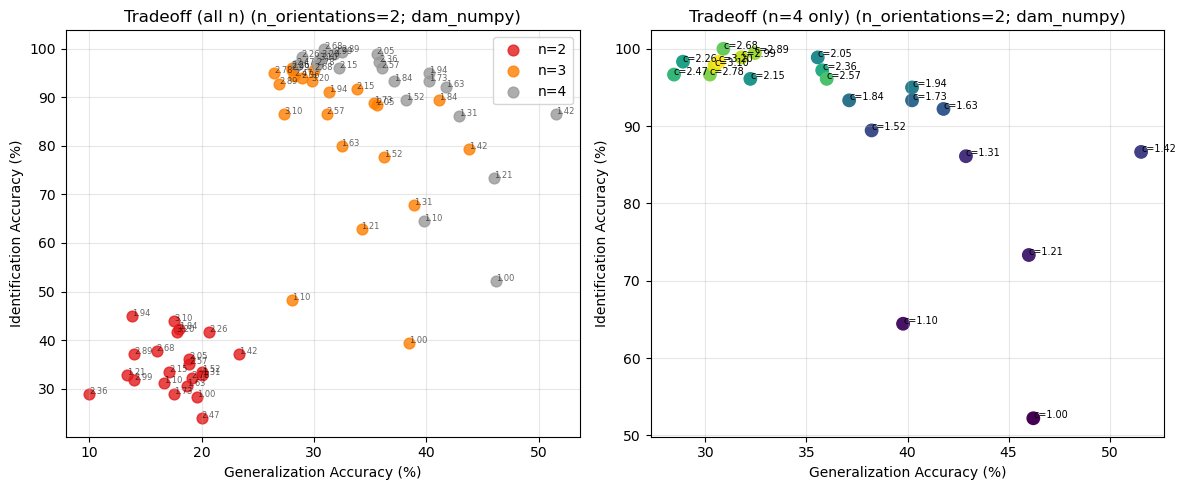

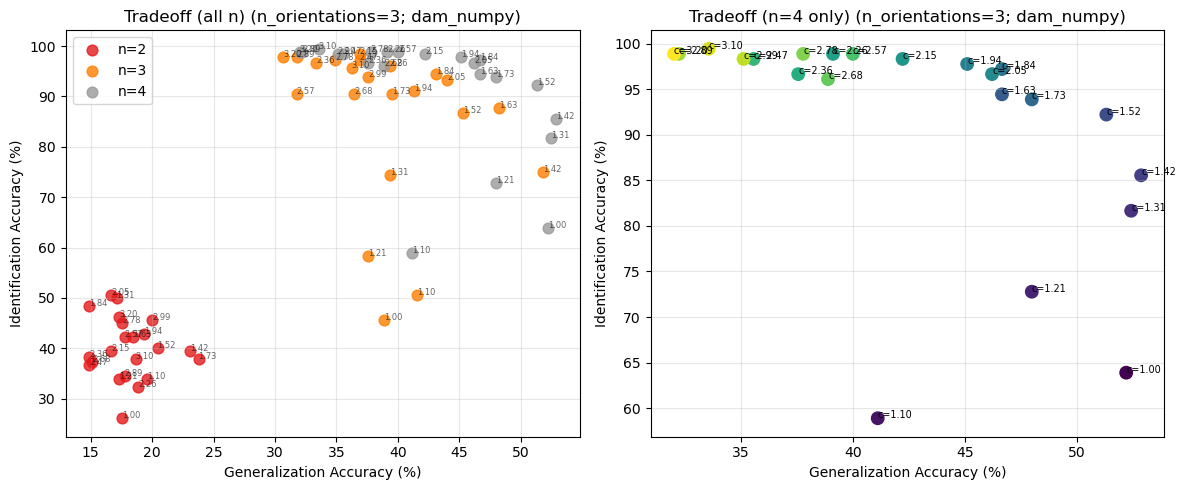

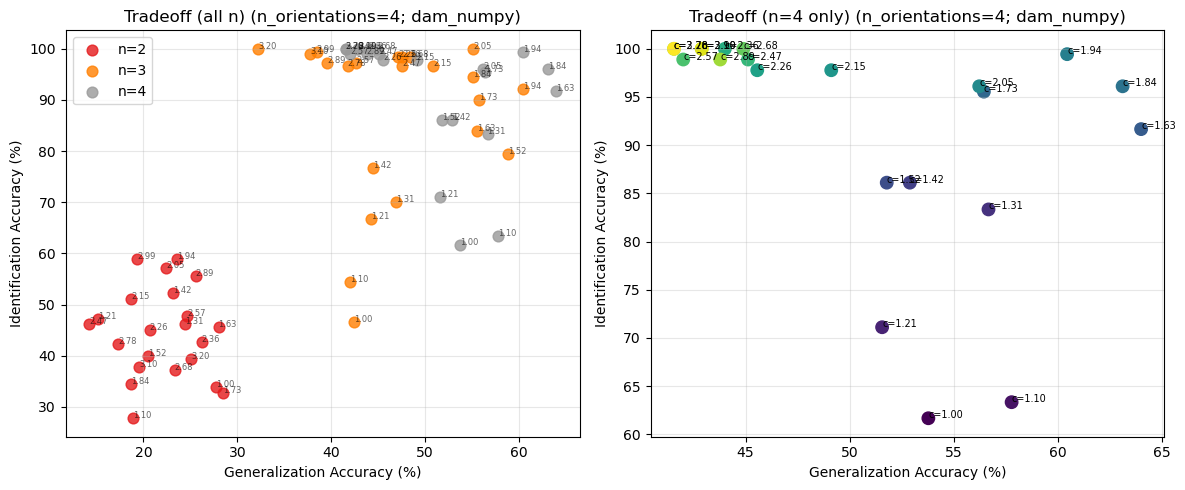

In [34]:
EXP1_SPEC = get_experiment_spec(0)
np.random.seed(SEED)
EXP1_NUMPY_ROWS, EXP1_NUMPY_DETAILS = run_single_experiment_variant(
    EXP1_SPEC,
    "dam_numpy",
    dam_only_optimized_pipeline,
)
print_run_rows(EXP1_NUMPY_ROWS, "Experiment 1 - DAM-only NumPy")

/var/folders/d6/36xrw9710mj5by0f76wq1tn80000gn/T/ipykernel_61393/3955658369.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


[dam_numba] Experiment 1: n_orientations | n_orientations=2 | runtime=6.88s | c_opt=1.419 | gen=51.6% | ident=86.7%
[dam_numba] Experiment 1: n_orientations | n_orientations=3 | runtime=9.24s | c_opt=1.419 | gen=52.9% | ident=85.6%
[dam_numba] Experiment 1: n_orientations | n_orientations=4 | runtime=11.29s | c_opt=1.629 | gen=64.0% | ident=91.7%

Experiment 1: n_orientations [dam_numba] summary: setting | optimum_c | gen_acc_at_opt | ident_acc_at_opt | runtime_s
  n_orientations=2  |  1.419  |  51.6%  | 86.7%  |  6.88s
  n_orientations=3  |  1.419  |  52.9%  | 85.6%  |  9.24s
  n_orientations=4  |  1.629  |  64.0%  | 91.7%  |  11.29s

Experiment 1 - DAM-only Numba
-----------------------------
variant          | experiment                         | setting                      | runtime_s |   c_opt |  gen@opt | ident@opt
---------------------------------------------------------------------------------------------------------------------------------
dam_numba        | Experiment 1: n_o

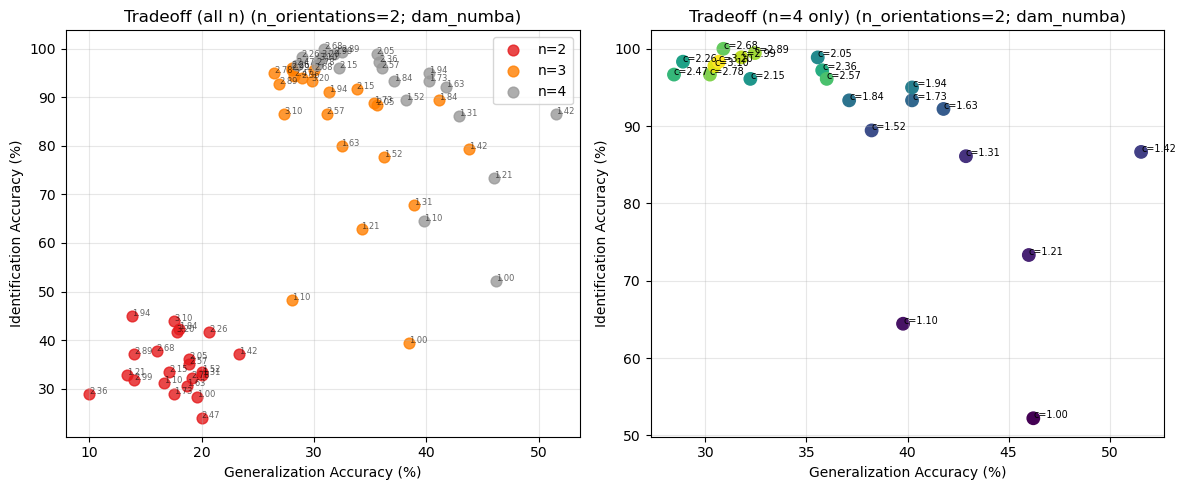

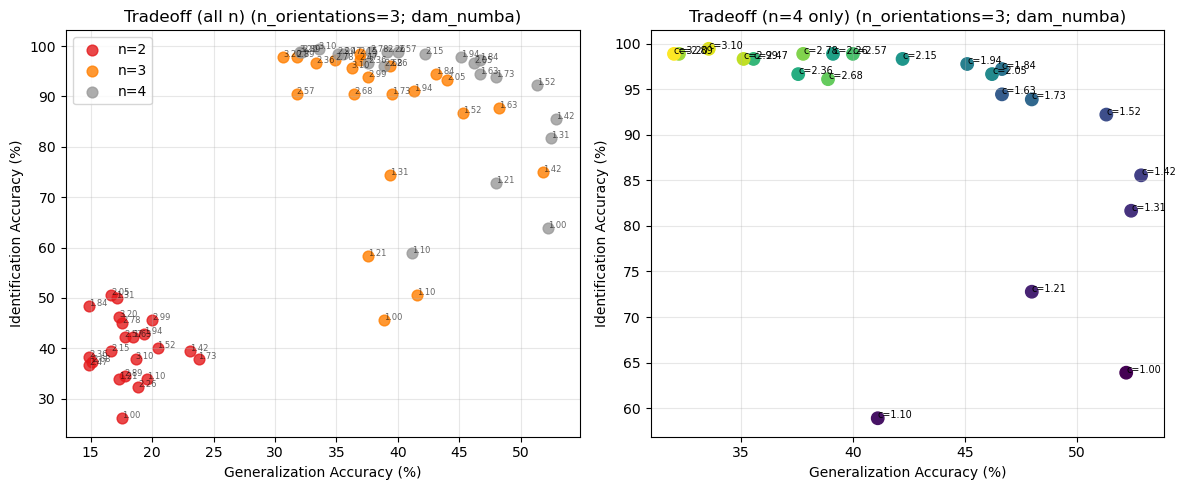

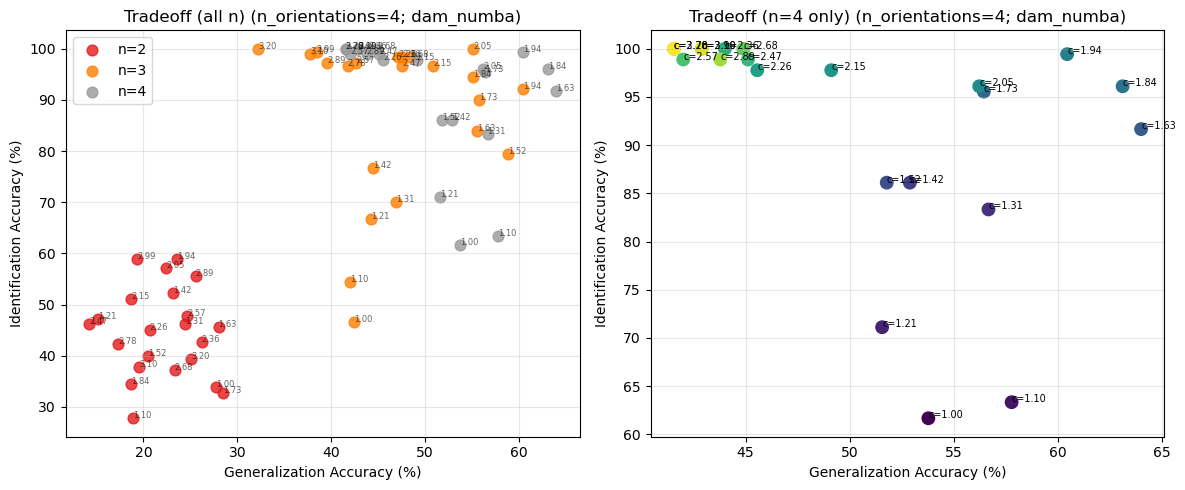

In [85]:
np.random.seed(SEED)
EXP1_NUMBA_ROWS, EXP1_NUMBA_DETAILS = run_single_experiment_numba(EXP1_SPEC)
if EXP1_NUMBA_ROWS:
    print_run_rows(EXP1_NUMBA_ROWS, "Experiment 1 - DAM-only Numba")

In [35]:
EXP1_COMPARISON = print_experiment_comparison(
    EXP1_SPEC["experiment_name"],
    EXP1_NUMPY_ROWS,
    EXP1_NUMBA_ROWS,
)


NumPy vs Numba comparison (full-size Part 4b)
---------------------------------------------
experiment                         | setting                      |   numpy_s |   numba_s |  speedup | c_opt_match |  Δgen@opt |  Δident@opt
--------------------------------------------------------------------------------------------------------------------------------------------
Experiment 1: n_orientations       | n_orientations=2             |   235.759 |     6.589 |  35.782x |        True |     +0.00 |       +0.00
Experiment 1: n_orientations       | n_orientations=3             |   348.972 |     9.005 |  38.754x |        True |     +0.00 |       +0.00
Experiment 1: n_orientations       | n_orientations=4             |   476.099 |    11.358 |  41.917x |        True |     +0.00 |       +0.00

[Experiment 1: n_orientations] aggregate speedup: mean=38.818x, median=38.754x


### Experiment 2: Base frequency q (0.3, 0.5, 0.7)

In [86]:
EXP2_SPEC = get_experiment_spec(1)
np.random.seed(SEED)
EXP2_NUMPY_ROWS, EXP2_NUMPY_DETAILS = run_single_experiment_variant(
    EXP2_SPEC,
    "dam_numpy",
    dam_only_optimized_pipeline,
)
print_run_rows(EXP2_NUMPY_ROWS, "Experiment 2 - DAM-only NumPy")

KeyboardInterrupt: 

/var/folders/d6/36xrw9710mj5by0f76wq1tn80000gn/T/ipykernel_61393/3955658369.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


[dam_numba] Experiment 2: base_freq | base_freq=0.3 | runtime=9.82s | c_opt=1.629 | gen=66.2% | ident=80.6%
[dam_numba] Experiment 2: base_freq | base_freq=0.5 | runtime=9.48s | c_opt=1.524 | gen=53.1% | ident=85.6%
[dam_numba] Experiment 2: base_freq | base_freq=0.7 | runtime=9.47s | c_opt=1.314 | gen=39.3% | ident=92.2%

Experiment 2: base_freq [dam_numba] summary: setting | optimum_c | gen_acc_at_opt | ident_acc_at_opt | runtime_s
  base_freq=0.3  |  1.629  |  66.2%  | 80.6%  |  9.82s
  base_freq=0.5  |  1.524  |  53.1%  | 85.6%  |  9.48s
  base_freq=0.7  |  1.314  |  39.3%  | 92.2%  |  9.47s

Experiment 2 - DAM-only Numba
-----------------------------
variant          | experiment                         | setting                      | runtime_s |   c_opt |  gen@opt | ident@opt
---------------------------------------------------------------------------------------------------------------------------------
dam_numba        | Experiment 2: base_freq            | base_freq=0.3       

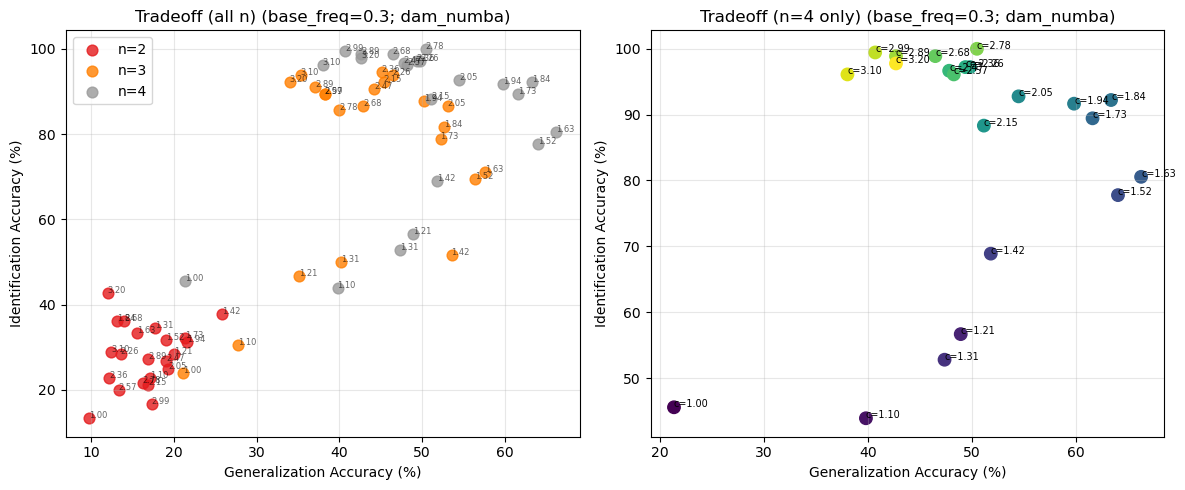

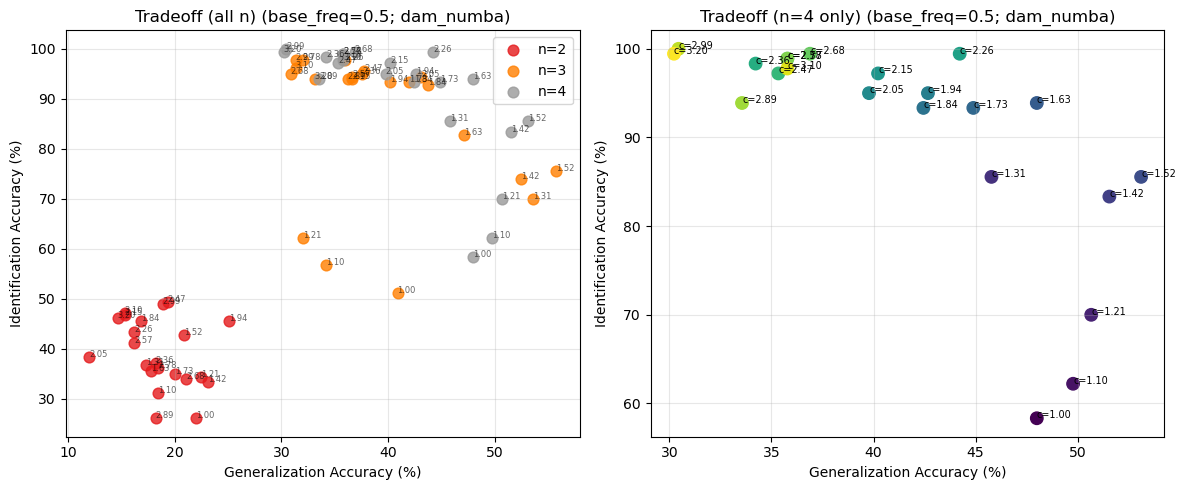

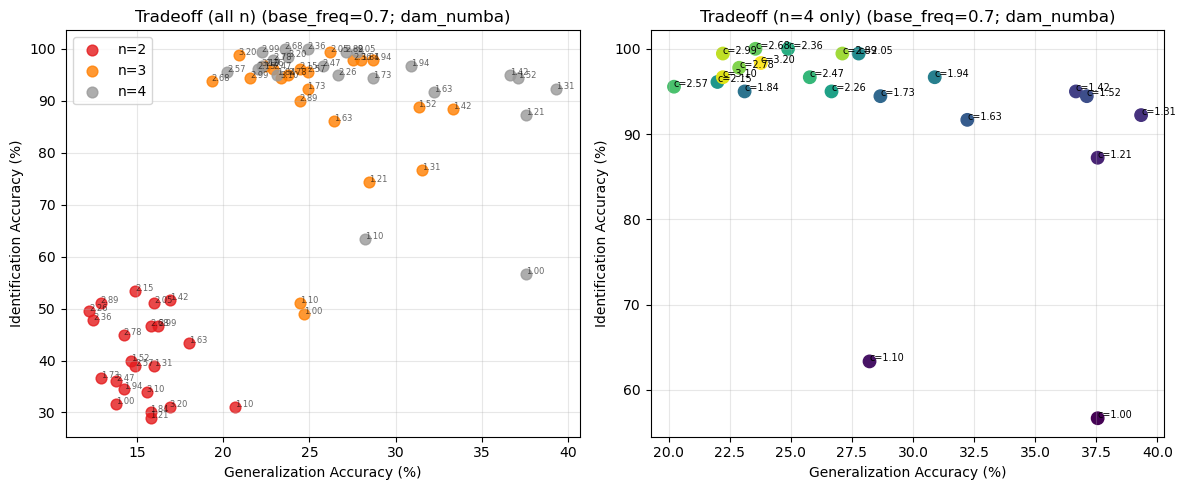

In [87]:
np.random.seed(SEED)
EXP2_NUMBA_ROWS, EXP2_NUMBA_DETAILS = run_single_experiment_numba(EXP2_SPEC)
if EXP2_NUMBA_ROWS:
    print_run_rows(EXP2_NUMBA_ROWS, "Experiment 2 - DAM-only Numba")

In [ ]:
EXP2_COMPARISON = print_experiment_comparison(
    EXP2_SPEC["experiment_name"],
    EXP2_NUMPY_ROWS,
    EXP2_NUMBA_ROWS,
)

### Experiment 3: Number of modules (3, 4, 5)

In [39]:
EXP3_SPEC = get_experiment_spec(2)
np.random.seed(SEED)
EXP3_NUMPY_ROWS, EXP3_NUMPY_DETAILS = run_single_experiment_variant(
    EXP3_SPEC,
    "dam_numpy",
    dam_only_optimized_pipeline,
)
print_run_rows(EXP3_NUMPY_ROWS, "Experiment 3 - DAM-only NumPy")

KeyboardInterrupt: 

/var/folders/d6/36xrw9710mj5by0f76wq1tn80000gn/T/ipykernel_61393/3955658369.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


[dam_numba] Experiment 3: n_modules | n_modules=3 | runtime=7.45s | c_opt=1.419 | gen=58.9% | ident=80.0%
[dam_numba] Experiment 3: n_modules | n_modules=4 | runtime=9.86s | c_opt=1.419 | gen=54.4% | ident=86.7%
[dam_numba] Experiment 3: n_modules | n_modules=5 | runtime=11.48s | c_opt=1.419 | gen=57.3% | ident=88.9%

Experiment 3: n_modules [dam_numba] summary: setting | optimum_c | gen_acc_at_opt | ident_acc_at_opt | runtime_s
  n_modules=3  |  1.419  |  58.9%  | 80.0%  |  7.45s
  n_modules=4  |  1.419  |  54.4%  | 86.7%  |  9.86s
  n_modules=5  |  1.419  |  57.3%  | 88.9%  |  11.48s

Experiment 3 - DAM-only Numba
-----------------------------
variant          | experiment                         | setting                      | runtime_s |   c_opt |  gen@opt | ident@opt
---------------------------------------------------------------------------------------------------------------------------------
dam_numba        | Experiment 3: n_modules            | n_modules=3                  |

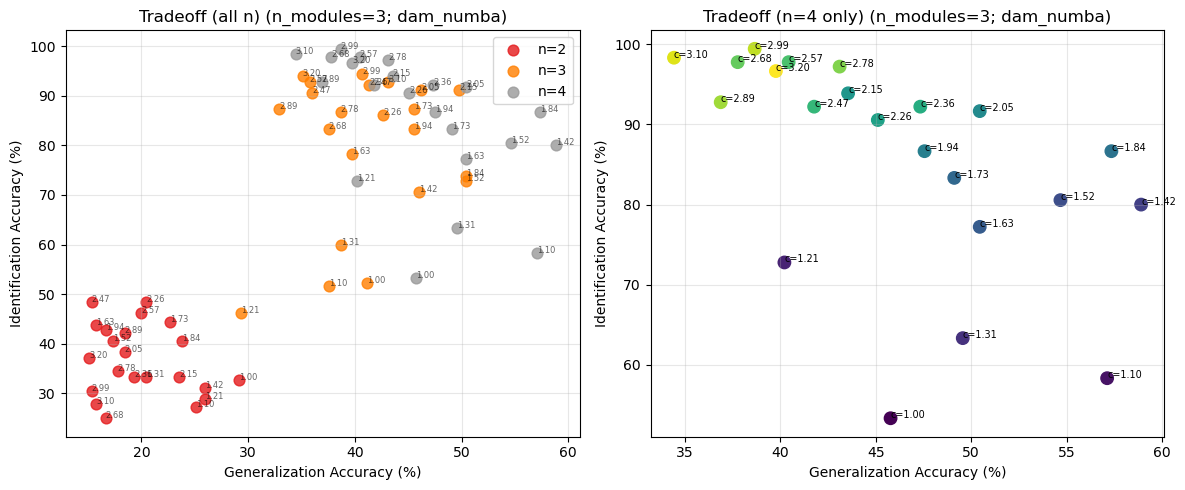

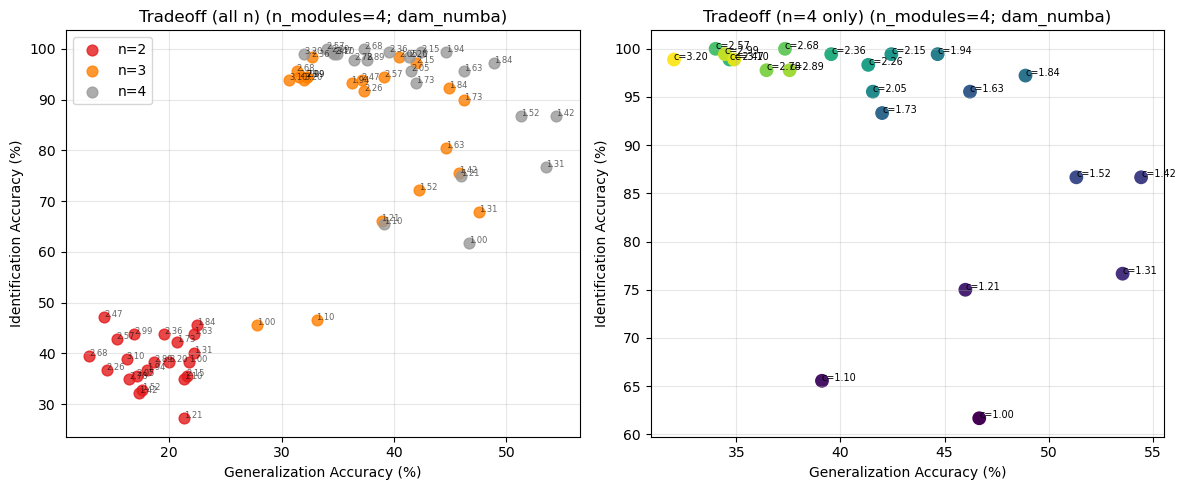

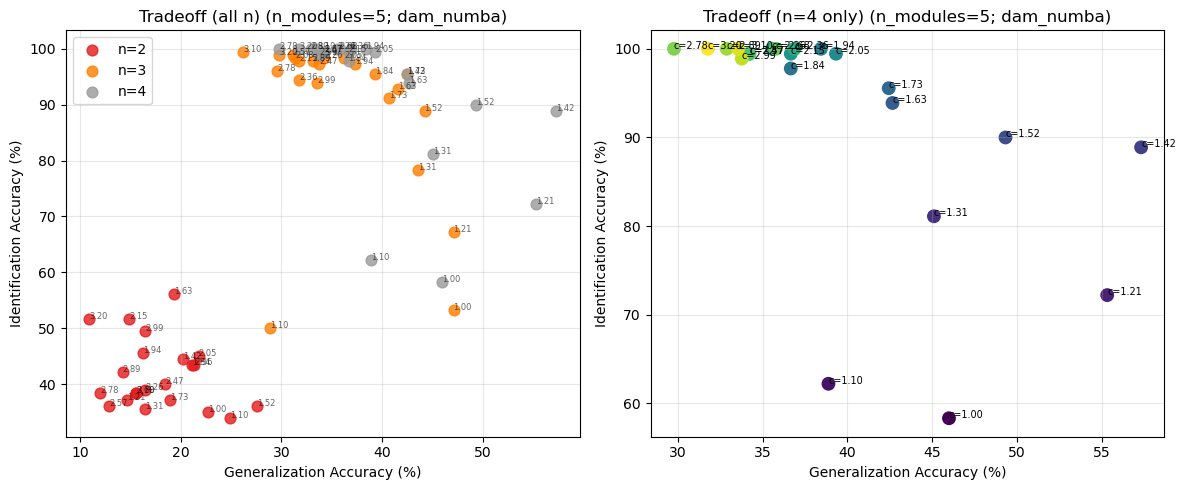

In [88]:
np.random.seed(SEED)
EXP3_NUMBA_ROWS, EXP3_NUMBA_DETAILS = run_single_experiment_numba(EXP3_SPEC)
if EXP3_NUMBA_ROWS:
    print_run_rows(EXP3_NUMBA_ROWS, "Experiment 3 - DAM-only Numba")

In [ ]:
EXP3_COMPARISON = print_experiment_comparison(
    EXP3_SPEC["experiment_name"],
    EXP3_NUMPY_ROWS,
    EXP3_NUMBA_ROWS,
)

### Experiment 4: Cells per orientation (3, 4, 6)

In [ ]:
EXP4_SPEC = get_experiment_spec(3)
np.random.seed(SEED)
EXP4_NUMPY_ROWS, EXP4_NUMPY_DETAILS = run_single_experiment_variant(
    EXP4_SPEC,
    "dam_numpy",
    dam_only_optimized_pipeline,
)
print_run_rows(EXP4_NUMPY_ROWS, "Experiment 4 - DAM-only NumPy")

KeyboardInterrupt: 

/var/folders/d6/36xrw9710mj5by0f76wq1tn80000gn/T/ipykernel_61393/3955658369.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


[dam_numba] Experiment 4: n_cells_per_orientation | n_cells_per_orientation=3 | runtime=7.54s | c_opt=1.419 | gen=53.8% | ident=81.7%
[dam_numba] Experiment 4: n_cells_per_orientation | n_cells_per_orientation=4 | runtime=9.77s | c_opt=1.419 | gen=54.4% | ident=86.7%
[dam_numba] Experiment 4: n_cells_per_orientation | n_cells_per_orientation=6 | runtime=12.14s | c_opt=1.524 | gen=54.0% | ident=81.1%

Experiment 4: n_cells_per_orientation [dam_numba] summary: setting | optimum_c | gen_acc_at_opt | ident_acc_at_opt | runtime_s
  n_cells_per_orientation=3  |  1.419  |  53.8%  | 81.7%  |  7.54s
  n_cells_per_orientation=4  |  1.419  |  54.4%  | 86.7%  |  9.77s
  n_cells_per_orientation=6  |  1.524  |  54.0%  | 81.1%  |  12.14s

Experiment 4 - DAM-only Numba
-----------------------------
variant          | experiment                         | setting                      | runtime_s |   c_opt |  gen@opt | ident@opt
----------------------------------------------------------------------------

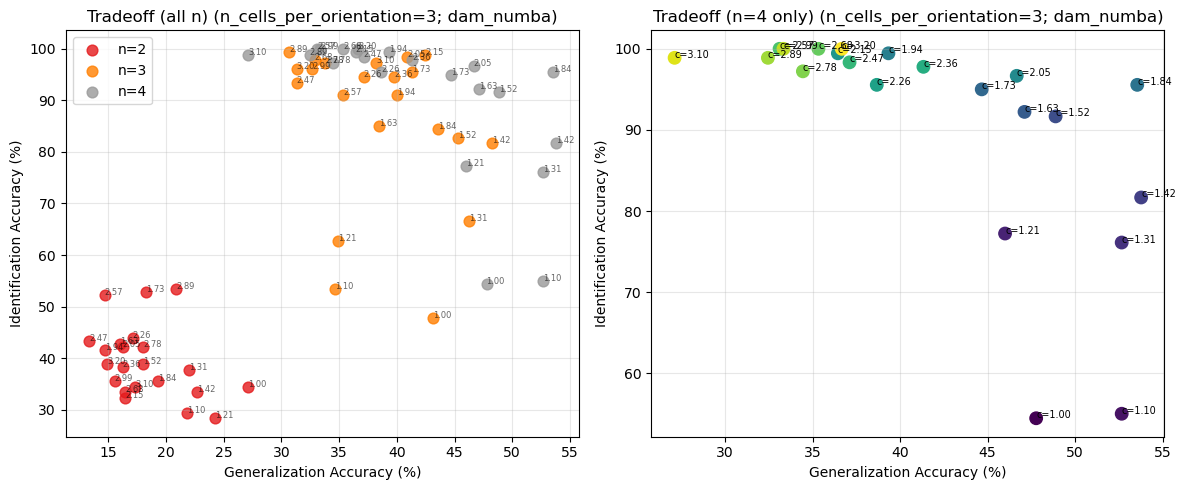

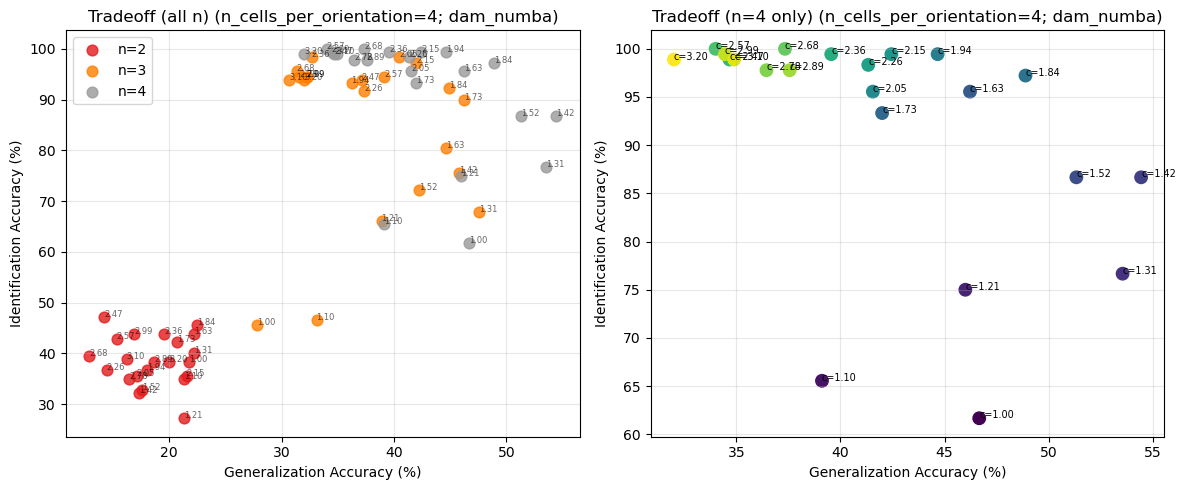

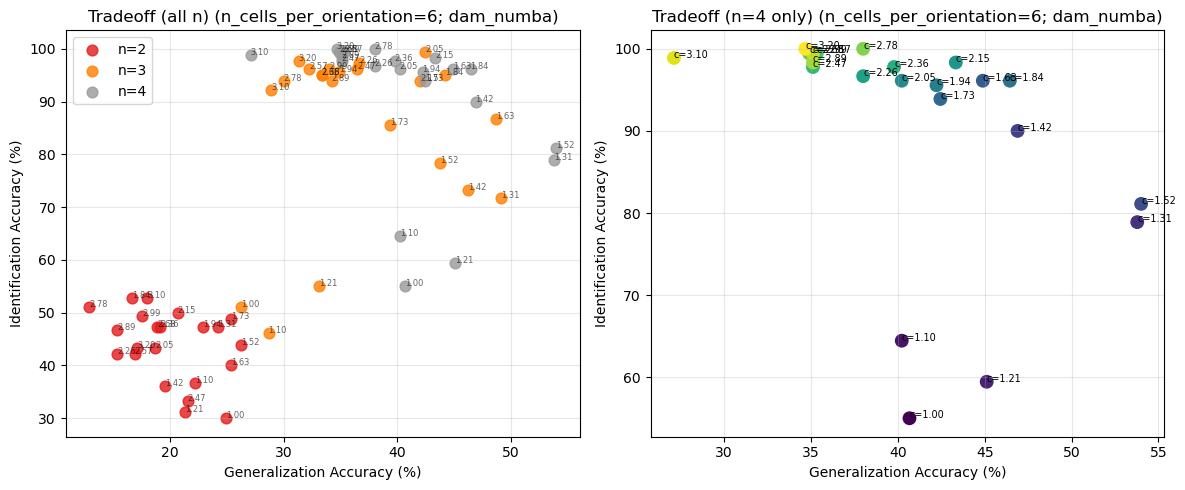

In [ ]:
np.random.seed(SEED)
EXP4_NUMBA_ROWS, EXP4_NUMBA_DETAILS = run_single_experiment_numba(EXP4_SPEC)
if EXP4_NUMBA_ROWS:
    print_run_rows(EXP4_NUMBA_ROWS, "Experiment 4 - DAM-only Numba")

In [ ]:
EXP4_COMPARISON = print_experiment_comparison(
    EXP4_SPEC["experiment_name"],
    EXP4_NUMPY_ROWS,
    EXP4_NUMBA_ROWS,
)

### Experiment 5: Input distribution (uniform, clustered, biased)

In [ ]:
EXP5_SPEC = get_experiment_spec(4)
np.random.seed(SEED)
EXP5_NUMPY_ROWS, EXP5_NUMPY_DETAILS = run_single_experiment_variant(
    EXP5_SPEC,
    "dam_numpy",
    dam_only_optimized_pipeline,
)
print_run_rows(EXP5_NUMPY_ROWS, "Experiment 5 - DAM-only NumPy")

In [ ]:
np.random.seed(SEED)
EXP5_NUMBA_ROWS, EXP5_NUMBA_DETAILS = run_single_experiment_numba(EXP5_SPEC)
if EXP5_NUMBA_ROWS:
    print_run_rows(EXP5_NUMBA_ROWS, "Experiment 5 - DAM-only Numba")

NameError: name 'EXP5_SPEC' is not defined

In [ ]:
EXP5_COMPARISON = print_experiment_comparison(
    EXP5_SPEC["experiment_name"],
    EXP5_NUMPY_ROWS,
    EXP5_NUMBA_ROWS,
)